In [1]:
%load_ext autoreload
%autoreload 2
%run -i loader/dataloader_hurricane.py
%run -i models/st_gat.py

In [2]:
from loader.dataloader_hurricane import *

# data_df=pd.read_csv("/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurricanes/stgat_traffic_prediction-main/Correlations/Ian_hydro.csv",low_memory=False).dropna()
data_df=pd.read_csv("../STOFSatl_hydro.csv", low_memory=False).dropna()
# data_df=pd.read_csv("all_hydro.csv", low_memory=False).dropna()
# station_info = pd.read_csv('stations_Ian.csv')
# data_df = data_df[(data_df['storm'] == 'CHARLEY') | (data_df['storm']=='ELSA') | (data_df['storm']=='IRMA') | (data_df['storm']=='ETA') | (data_df['storm']=='WILMA') | ((data_df['storm']=='HERMINE') & (data_df['year'] == 2016)) | (data_df['storm']=='IAN')].dropna()
# Remove outliers
std = data_df['offset'].std()
data_df = data_df.where(data_df['offset'].abs() < 3*np.abs(std)).dropna()

# data_df = data_df.where(data_df['offset'].abs() < 3*np.abs(std)).dropna()


print("Storms:")
print(data_df['storm'].unique())

Storms:
['CHARLEY' 'HERMINE' 'MATTHEW' 'HARVEY' 'IDA' 'IAN' 'IDALIA']


In [3]:
# Keep only stations on the East Coast

# data_df = data_df[(data_df['x'] > -81.871) & (data_df['y'] > 24.711)].dropna()

data_df = data_df[(data_df['x'] < -81.875)].dropna()

In [4]:
# Find common station IDs through all storms

storms = data_df['storm'].unique()
ids_per_storm = {}
for storm in storms:
    ids_per_storm[storm] = data_df[data_df['storm']==storm]['station_id'].unique().tolist()

common_ids = list(set.intersection(*map(set, [ids_per_storm[storm] for storm in storms])))
print("No. of common stations before droping NaN values:")
print(len(common_ids))

No. of common stations before droping NaN values:
27


In [5]:
# data_df

In [6]:
# data_df[data_df['storm'] == 'IDALIA']['station_id'].unique()

In [7]:
# data_df[data_df['storm'] == 'CHARLEY']['station_id'].unique()

In [8]:
station_info_df = data_df[data_df['station_id'].isin(common_ids)][['x', 'y', 'station_id', 'agency']].drop_duplicates()
print(station_info_df['agency'].unique())

['USACE' 'NOAA_NOS' 'TCOON']


In [9]:

import matplotlib.pyplot as plt
import matplotlib as mpl

import cartopy.crs as crs
import cartopy.feature as cfeature

def scale_bar(ax, length=None, location=(0.5, 0.05), linewidth=3):
    """
    ax is the axes to draw the scalebar on.
    length is the length of the scalebar in km.
    location is center of the scalebar in axis coordinates.
    (ie. 0.5 is the middle of the plot)
    linewidth is the thickness of the scalebar.
    """
    #Get the limits of the axis in lat long
    llx0, llx1, lly0, lly1 = ax.get_extent(crs.PlateCarree())
    #Make tmc horizontally centred on the middle of the map,
    #vertically at scale bar location
    sbllx = (llx1 + llx0) / 2
    sblly = lly0 + (lly1 - lly0) * location[1]
    tmc = crs.TransverseMercator(sbllx, sblly)
    #Get the extent of the plotted area in coordinates in metres
    x0, x1, y0, y1 = ax.get_extent(tmc)
    #Turn the specified scalebar location into coordinates in metres
    sbx = x0 + (x1 - x0) * location[0]
    sby = y0 + (y1 - y0) * location[1]

    #Calculate a scale bar length if none has been given
    #(Theres probably a more pythonic way of rounding the number but this works)
    if not length: 
        length = (x1 - x0) / 5000 #in km
        ndim = int(np.floor(np.log10(length))) #number of digits in number
        length = round(length, -ndim) #round to 1sf
        #Returns numbers starting with the list
        def scale_number(x):
            if str(x)[0] in ['1', '2', '5']: return int(x)        
            else: return scale_number(x - 10 ** ndim)
        length = scale_number(length) 

    #Generate the x coordinate for the ends of the scalebar
    bar_xs = [sbx - length * 500, sbx + length * 500]
    #Plot the scalebar
    ax.plot(bar_xs, [sby, sby], transform=tmc, color='k', linewidth=linewidth)
    #Plot the scalebar label
    ax.text(sbx, sby, str(length) + ' km', transform=tmc,
            horizontalalignment='center', verticalalignment='bottom')

c:\Users\stefanos\Documents\venv\pytorch\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


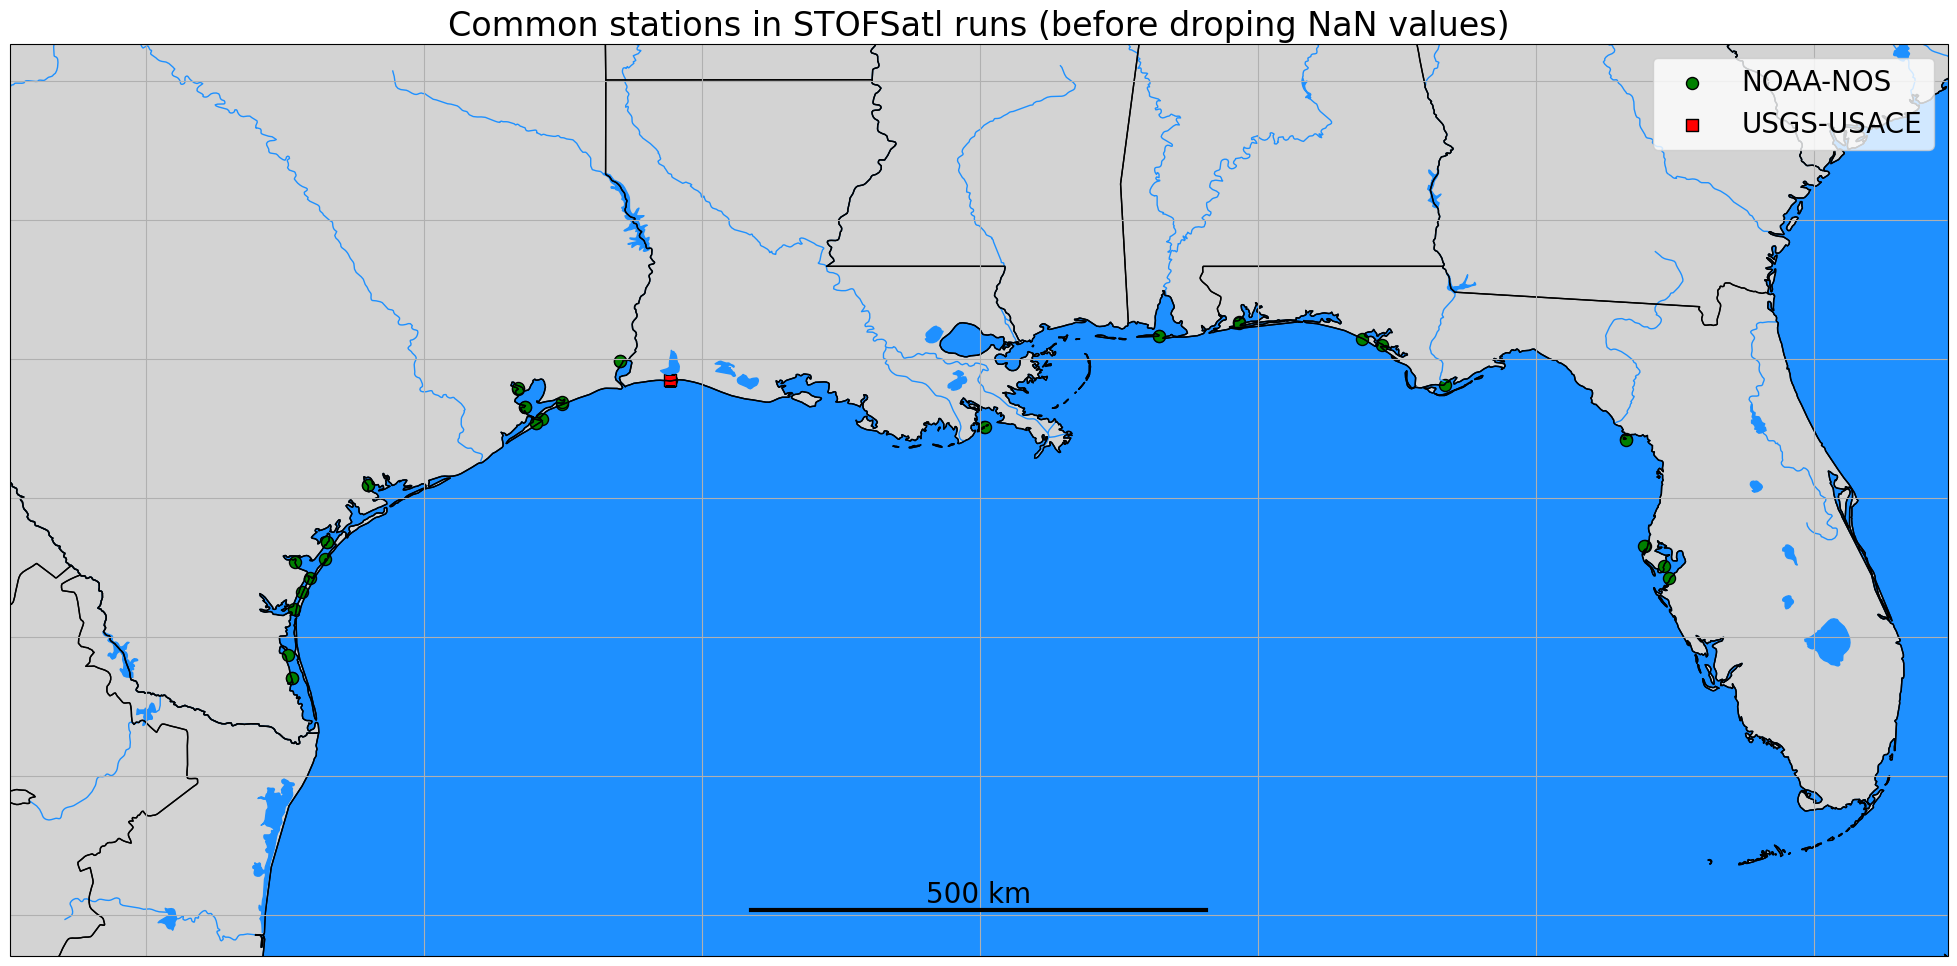

In [10]:
station_info_df_NOOA = station_info_df[(station_info_df['agency'] == 'NOAA_NOS') | (station_info_df['agency'] == 'TCOON')]
station_info_df_USGS = station_info_df[(station_info_df['agency'] == 'USGS') | (station_info_df['agency'] == 'USACE')]



plt.rcParams['figure.figsize'] = [25, 12.5]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

im1 = ax.scatter(station_info_df_NOOA['x'], station_info_df_NOOA['y'], c = 'green',
                  edgecolors='black',
                    s=75,
                      alpha=1.0,
                        label='NOAA-NOS')
im2 = ax.scatter(station_info_df_USGS['x'], station_info_df_USGS['y'], c = 'red',
                  marker = 's',
                    edgecolors='black',
                      s=75, alpha=1.0,
                        label='USGS-USACE')

plt.xlim((station_info_df['x'].min()-3, station_info_df['x'].max()+3))
plt.ylim((station_info_df['y'].min()-3, station_info_df['y'].max()+3))

plt.legend()
scale_bar(ax, 500)
plt.title('Common stations in STOFSatl runs (before droping NaN values)')
plt.show()

In [11]:
# Constant config to use throughout
config = {
    'BATCH_SIZE': 20,
    'EPOCHS': 200,
    'WEIGHT_DECAY': 5e-7, #5e-5
    'INITIAL_LR': 3e-5,   #3e-4
    'CHECKPOINT_DIR': './runs',
    'N_PRED': 9,
    'N_HIST': 15,
    'DROPOUT': 0.4,      #0.2
    # number of possible 5 minute measurements per day
    # number of days worth of data in the dataset
    # If false, use GCN paper weight matrix, if true, use GAT paper weight matrix
    'USE_GAT_WEIGHTS': True,
    # ['CHARLEY' 'HERMINE' 'MATTHEW' 'HARVEY' 'IDA' 'IAN' 'IDALIA']
    # ['CHARLEY' 'WILMA' 'HERMINE' 'IRMA' 'ETA' 'ELSA' 'IAN']
    'SPLITS': {
    # 'TRAIN_STORMS': ['CHARLEY', 'HERMINE', 'MATTHEW', 'HARVEY', 'IDA']
    'TRAIN_STORMS': ['CHARLEY', 'HERMINE'],
    # 'TRAIN_STORMS': ['CHARLEY', 'WILMA', 'HERMINE', 'IRMA', 'ELSA'],
    'VAL_STORMS': ['IAN'],
    'TEST_STORMS': ['IDALIA'],
    }
}
# Number of possible windows in a day
# config['N_SLOT']= config['N_DAY_SLOT'] - (config['N_PRED']+config['N_HIST']) + 1

In [12]:
# # Test sliding window
# Ids=data_df['station_id'].unique()   


# df_train, df_val, df_test = get_splits_hurricanes(data_df, config['SPLITS'])

# station_df_train =create_stationDf(df_train, Ids, 'offset')
# station_df_val =create_stationDf(df_val, Ids, 'offset')
# station_df_test =create_stationDf(df_test, Ids, 'offset')

# new_common_ids = list(set(station_df_train.columns.values) & set(station_df_val.columns.values) & set(station_df_test.columns.values))
# station_df_train = station_df_train[station_df_train.columns.intersection(new_common_ids)]
# station_df_val = station_df_val[station_df_val.columns.intersection(new_common_ids)]
# station_df_test = station_df_test[station_df_test.columns.intersection(new_common_ids)]

# sliding_step=config['N_PRED']

# n_window = config['N_PRED'] + config['N_HIST'] # full window length


# # config['N_Windows']=int(len(station_df)/n_window)  # Works only for non-overlapping windows
# config['N_Windows'] = int((len(station_df_train) - n_window)/sliding_step)+1

# x = np.ones((station_df_train.shape[1], config['N_HIST']*config['N_Windows']))*np.nan
# y = np.ones((station_df_train.shape[1], config['N_PRED']*config['N_Windows']))*np.nan


# # full_window = np.ones((station_df.shape[1], n_window*config['N_Windows']))*np.nan

# # print(n_window)
# # print(sliding_step)
# # print(config['N_Windows'])

# # print(full_window.shape[1])


# for count, i in enumerate(range(0, len(station_df_test), sliding_step)):
#     # save_dir_str = r"C:\Users\Stefanos\Desktop\ST_GNN_train\\"
#     # fname_str = 'x_' + str(count) + '.txt'
#     # np.savetxt(save_dir_str+fname_str, x, fmt='%.4f')

#     # fname_str = 'y_' + str(count) + '.txt'
#     # np.savetxt(save_dir_str+fname_str, y, fmt='%.4f')


#     sta=i
#     end = sta + n_window
    
#     if end > len(station_df_test):
#         break

#     data=np.array(station_df_test.iloc[sta:end,:].values)
#     data=np.swapaxes(data, 0, 1) #data is the offset of all stations
#     # print("Data shape: ", data.shape)
#     x[:,count*config['N_HIST']:count*config['N_HIST']+config['N_HIST']] = data[:, :config['N_HIST']]
#     y[:,count*config['N_PRED']:count*config['N_PRED']+config['N_PRED']] = data[:, config['N_HIST']::]
# print(count)

In [13]:
# plt.plot(x[1,:].flatten())
# plt.show()

In [14]:
# x_scaler = MinMaxScaler().fit(x.reshape(-1,1))
# x_scaled = x_scaler.transform(x.reshape(-1,1)).reshape(x.shape[0], x.shape[1])

# y_scaler = MinMaxScaler().fit(y.reshape(-1,1))
# y_scaled = y_scaler.transform(y.reshape(-1,1)).reshape(y.shape[0], y.shape[1])

In [15]:
# plt.plot(x_scaled[1,:].flatten())
# plt.show()

In [16]:
# save_dir_str = r"C:\Users\Stefanos\Desktop\\"
# fname_str = 'y_test' +  '.txt'
# np.savetxt(save_dir_str+fname_str, y, fmt='%.4f')
# print(y[0,:])

In [17]:
# plt.plot(y[2, :])
# plt.show()


In [18]:
# # Apply sliding window
# x_train, y_train = sliding_window(station_df_train, config, 1)
# x_val, y_val = sliding_window(station_df_val, config, 1)
# x_test, y_test = sliding_window(station_df_test, config, config['N_PRED'])

# # Scale data
# x_scaler = MinMaxScaler().fit(x_train.reshape(-1,1))
# x_train_scaled = x_scaler.transform(x_train.reshape(-1,1)).reshape(x_train.shape[0], x_train.shape[1])
# x_val_scaled = x_scaler.transform(x_val.reshape(-1,1)).reshape(x_val.shape[0], x_val.shape[1])
# x_test_scaled = x_scaler.transform(x_test.reshape(-1,1)).reshape(x_test.shape[0], x_test.shape[1])

# y_scaler = MinMaxScaler().fit(y_train.reshape(-1,1))
# y_train_scaled = y_scaler.transform(y_train.reshape(-1,1)).reshape(y_train.shape[0], y_train.shape[1])
# y_val_scaled = y_scaler.transform(y_val.reshape(-1,1)).reshape(y_val.shape[0], y_val.shape[1])
# y_test_scaled = y_scaler.transform(y_test.reshape(-1,1)).reshape(y_test.shape[0], y_test.shape[1])

# row = 24
# fig, ax = plt.subplots(1,3, sharey=False)
# ax[2].plot(y_train_scaled[row, :], '.-')
# ax[2].set_title('scaled')
# ax[1].plot(y_train[row, :], '.-')
# ax[1].set_title('unscaled')
# ax[0].plot(station_df_test.iloc[:, row], '.-')
# ax[0].set_title('original')
# plt.show()

# fig, ax = plt.subplots(1,3, sharey=False)
# ax[2].plot(x_train_scaled[row, :], '.-')
# ax[2].set_title('scaled')
# ax[1].plot(x_train[row, :], '.-')
# ax[1].set_title('unscaled')
# ax[0].plot(station_df_train.iloc[:, row], '.-')
# ax[0].set_title('original')
# plt.show()


In [19]:
# W_mask=1000
# Corr_mask=0.7

# W=get_distance(df_train, station_df_train)
# Corr=get_correlation(df_train, station_df_train)
# adj_matrix=create_adjancency_matrix(W,Corr, W_mask, Corr_mask)
    
# _,n_node = W.shape
# n_window = config['N_PRED'] + config['N_HIST'] # full window taken per time t


# edge_attr = torch.zeros((n_node**2, 1))
# edge_index = torch.nonzero(torch.from_numpy(adj_matrix)).t()
# mask = edge_index[0] != edge_index[1] #mask to remove self loop edges
# filtered_edge_index = edge_index[:, mask] #remove self loop edges
# edge_index=filtered_edge_index

# edge_attr = adj_matrix[filtered_edge_index[0], filtered_edge_index[1]] #get edges attributes 
# # edge_attr = edge_attr.resize_(edge_attr.shape[0], 1)

In [20]:
# timesteps = len(station_df_train)
# sequences = []

# for i in range(timesteps):

#     g = Data()
#     g.__num_nodes__ = n_node

#     g.edge_index = edge_index
#     g.edge_attr  = edge_attr

#     x_start = i*config['N_HIST']
#     x_end = i*config['N_HIST']+config['N_HIST']
#     y_start = i*config['N_PRED']
#     y_end = i*config['N_PRED']+config['N_PRED']

#     if (x_end > x.shape[1]) or (y_end > y.shape[1]):
#         break

#     g.x = torch.FloatTensor(x_train_scaled[:,x_start:x_end]) #input first n past points
#     g.y = torch.FloatTensor(y_train_scaled[:,y_start:y_end]) #output predicted after n points
#     sequences += [g]

In [21]:
# print(len(sequences))
# print(sequences[0].y.shape[:])
# # y_read = np.ones((sequences[0].y.shape[0], sequences[0].y.shape[1]*len(sequences)))*np.nan
# # x_read = np.ones((sequences[0].x.shape[0], sequences[0].x.shape[1]*len(sequences)))*np.nan
# x_read = np.array([]).reshape(sequences[0].x.shape[0], 0)
# y_read = np.array([]).reshape(sequences[0].y.shape[0], 0)

# for seq in range(len(sequences)):
#     y_read_seq = sequences[seq].y.detach().numpy()
#     y_read =np.concatenate((y_read, y_read_seq), axis=1)
#     # y_read[:,seq*sequences[0].y.shape[1]:seq*sequences[0].y.shape[1]+sequences[0].y.shape[1]] = y_read_seq[:,:]
#     x_read_seq = sequences[seq].x.detach().numpy()
#     x_read = np.concatenate((x_read, x_read_seq), axis=1)

#     # x_read[:,seq*sequences[0].x.shape[1]:seq*sequences[0].x.shape[1]+sequences[0].x.shape[1]] = x_read_seq[:,:]
# print(x_read.shape[:])

In [22]:
# row = 24
# fig, ax = plt.subplots(1,4, sharey=False)
# ax[2].plot(y_train_scaled[row, :], '.-')
# ax[2].set_title('scaled')
# ax[1].plot(y_train[row, :], '.-')
# ax[1].set_title('unscaled')
# ax[0].plot(station_df_train.iloc[:, row], '.-')
# ax[0].set_title('original')
# ax[3].plot(y_read[row,:], '.-')
# ax[3].set_title('From graph object')
# plt.show()


In [23]:
# original = station_df_train.iloc[:, row]
# orignal = original[~np.isnan(original)]
# print(original.shape[:])

In [24]:
# xaxis = range(0, 15)

# fig, ax = plt.subplots(1,6, sharey=True)


# seq = 0*config['N_HIST']
# ax[0].plot(xaxis, x_train[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], '.-', label='scaled')
# ax[0].plot(xaxis, x_read[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], label = 'graph - read')
# ax[0].plot(xaxis, sequences[seq].x[row,:].detach().numpy(), label = 'graph - original')
# original = station_df_train.iloc[:config['N_HIST'], row]
# orignal = original[~np.isnan(original)]
# print(orignal.shape[:])
# ax[0].plot(xaxis, original, label='original')
# ax[0].legend()

# seq = 1*config['N_HIST']
# ax[1].plot(xaxis, x_train[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], '.-', label='scaled')
# ax[1].plot(xaxis, x_read[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], label = 'graph - read')
# ax[1].plot(xaxis, sequences[seq].x[row,:].detach().numpy(), label = 'graph - original')
# original = station_df_train.iloc[config['N_HIST']:2*config['N_HIST'], row]
# orignal = original[~np.isnan(original)]
# print(orignal.shape[:])
# ax[1].plot(xaxis, original, label='original')
# # ax[1].legend()


# seq = 2*config['N_HIST']
# ax[2].plot(xaxis, x_train[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], '.-', label='scaled')
# ax[2].plot(xaxis, x_read[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], label = 'graph - read')
# ax[2].plot(xaxis, sequences[seq].x[row,:].detach().numpy(), label = 'graph - original')
# original = station_df_train.iloc[2*config['N_HIST']:3*config['N_HIST'], row]
# orignal = original[~np.isnan(original)]
# print(orignal.shape[:])

# ax[2].plot(xaxis, original, label='original')
# # ax[2].legend()

# seq = 3*config['N_HIST']
# ax[3].plot(xaxis, x_train[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], '.-', label='scaled')
# ax[3].plot(xaxis, x_read[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], label = 'graph - read')
# ax[3].plot(xaxis, sequences[seq].x[row,:].detach().numpy(), label = 'graph - original')
# original = station_df_train.iloc[3*config['N_HIST']:4*config['N_HIST'], row]
# orignal = original[~np.isnan(original)]
# print(orignal.shape[:])

# ax[3].plot(xaxis, original, label='original')
# # ax[3].legend()

# seq = 4*config['N_HIST']
# ax[4].plot(xaxis, x_train[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], '.-', label='scaled')
# ax[4].plot(xaxis, x_read[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], label = 'graph - read')
# ax[4].plot(xaxis, sequences[seq].x[row,:].detach().numpy(), label = 'graph - original')
# original = station_df_train.iloc[4*config['N_HIST']:5*config['N_HIST'], row]
# orignal = original[~np.isnan(original)]
# print(orignal.shape[:])

# ax[4].plot(xaxis, original, label='original')
# # ax[4].legend()

# seq = 5*config['N_HIST']
# ax[5].plot(xaxis, x_train[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], '.-', label='scaled')
# ax[5].plot(xaxis, x_read[row, seq*config['N_HIST']:(seq+1)*config['N_HIST']], label = 'graph - read')
# ax[5].plot(xaxis, sequences[seq].x[row,:].detach().numpy(), label = 'graph - original')
# original = station_df_train.iloc[5*config['N_HIST']:6*config['N_HIST'], row]
# orignal = original[~np.isnan(original)]
# print(orignal.shape[:])

# ax[5].plot(xaxis, original, label='original')
# # ax[5].legend()

# plt.show()



In [25]:
# row = 24
# fig, ax = plt.subplots(1,4, sharey=False)
# ax[2].plot(x_train_scaled[row, :], '.-')
# ax[2].set_title('scaled')
# ax[1].plot(x_train[row, :], '.-')
# ax[1].set_title('unscaled')
# ax[0].plot(station_df_train.iloc[:, row], '.-')
# ax[0].set_title('original')
# ax[3].plot(x_read[row,:], '.-')
# ax[3].set_title('From graph object')
# plt.show()

In [26]:
# plt.plot(x_train[row, :], '.')
# plt.show()


In [27]:
# timesteps = len(station_df_test)
# sequences = []

# for i in range(timesteps):

#     # for each time point construct a different graph with data object
#     # Docs here: https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data
#     g = Data()
#     g.__num_nodes__ = n_node

#     g.edge_index = edge_index
#     g.edge_attr  = edge_attr

#     x_start = i*config['N_HIST']
#     x_end = i*config['N_HIST']+config['N_HIST']
#     y_start = i*config['N_PRED']
#     y_end = i*config['N_PRED']+config['N_PRED']

#     if (x_end > x.shape[1]) or (y_end > y.shape[1]):
#         break

#     g.x = torch.FloatTensor(x_test_scaled[:,x_start:x_end]) #input first n past points
#     g.y = torch.FloatTensor(y_test_scaled[:,y_start:y_end]) #output predicted after n points
#     sequences += [g]

# print(len(sequences))
# print(sequences[0].y.shape[:])
# # y_read = np.ones((sequences[0].y.shape[0], sequences[0].y.shape[1]*len(sequences)))*np.nan
# # x_read = np.ones((sequences[0].x.shape[0], sequences[0].x.shape[1]*len(sequences)))*np.nan
# x_read = np.array([]).reshape(sequences[0].x.shape[0], 0)
# y_read = np.array([]).reshape(sequences[0].y.shape[0], 0)

# for seq in range(len(sequences)):
#     y_read_seq = sequences[seq].y.detach().numpy()
#     y_read =np.concatenate((y_read, y_read_seq), axis=1)
#     # y_read[:,seq*sequences[0].y.shape[1]:seq*sequences[0].y.shape[1]+sequences[0].y.shape[1]] = y_read_seq[:,:]
#     x_read_seq = sequences[seq].x.detach().numpy()
#     x_read = np.concatenate((x_read, x_read_seq), axis=1)

#     # x_read[:,seq*sequences[0].x.shape[1]:seq*sequences[0].x.shape[1]+sequences[0].x.shape[1]] = x_read_seq[:,:]

# row = 1
# fig, ax = plt.subplots(1,4, sharey=False)
# ax[2].plot(y_test_scaled[row, :], '.-')
# ax[2].set_title('scaled')
# ax[1].plot(y_test[row, :], '.-')
# ax[1].set_title('unscaled')
# ax[0].plot(station_df_test.iloc[:, row], '.-')
# ax[0].set_title('original')
# ax[3].plot(y_read[row,:], '.-')
# ax[3].set_title('From graph object')
# plt.show()




In [28]:
# row = 1
# fig, ax = plt.subplots(1,4, sharey=False)
# ax[2].plot(x_test_scaled[row, :], '.-')
# ax[2].set_title('scaled')
# ax[1].plot(x_test[row, :], '.-')
# ax[1].set_title('unscaled')
# ax[0].plot(station_df_test.iloc[:, row], '.-')
# ax[0].set_title('original')
# ax[3].plot(x_test[row,:], '.-')
# ax[3].set_title('From graph object')
# plt.show()

In [29]:
Ids=data_df['station_id'].unique()   
station_df=create_stationDf(data_df,Ids, 'offset')
config['N_NODE'] = station_df.shape[1]
# print(station_df.shape)
# print(station_df.tail(20))
print("Number of common stations after droping NaN values\n", len(station_df.columns.values))
# Ids = station_df.columns.values

# Split df based on config["SPLITS"]
df_train, df_val, df_test = get_splits_hurricanes(data_df, config['SPLITS'])

# Create station df_* from df_*
station_df_train =create_stationDf(df_train, Ids, 'offset')
station_df_val =create_stationDf(df_val, Ids, 'offset')
station_df_test =create_stationDf(df_test, Ids, 'offset')

new_common_ids = list(set(station_df_train.columns.values) & set(station_df_val.columns.values) & set(station_df_test.columns.values))
station_df_train = station_df_train[station_df_train.columns.intersection(new_common_ids)]
station_df_val = station_df_val[station_df_val.columns.intersection(new_common_ids)]
station_df_test = station_df_test[station_df_test.columns.intersection(new_common_ids)]

print("Number of common stations after splitting\n", len(new_common_ids))


Number of common stations after droping NaN values
 17
Number of common stations after splitting
 19


In [30]:
station_info_df = data_df[data_df['station_id'].isin(station_df.columns.values)][['x', 'y', 'station_id', 'agency']].drop_duplicates()
print(station_info_df['agency'].unique())

['NOAA_NOS' 'TCOON']


c:\Users\stefanos\Documents\venv\pytorch\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


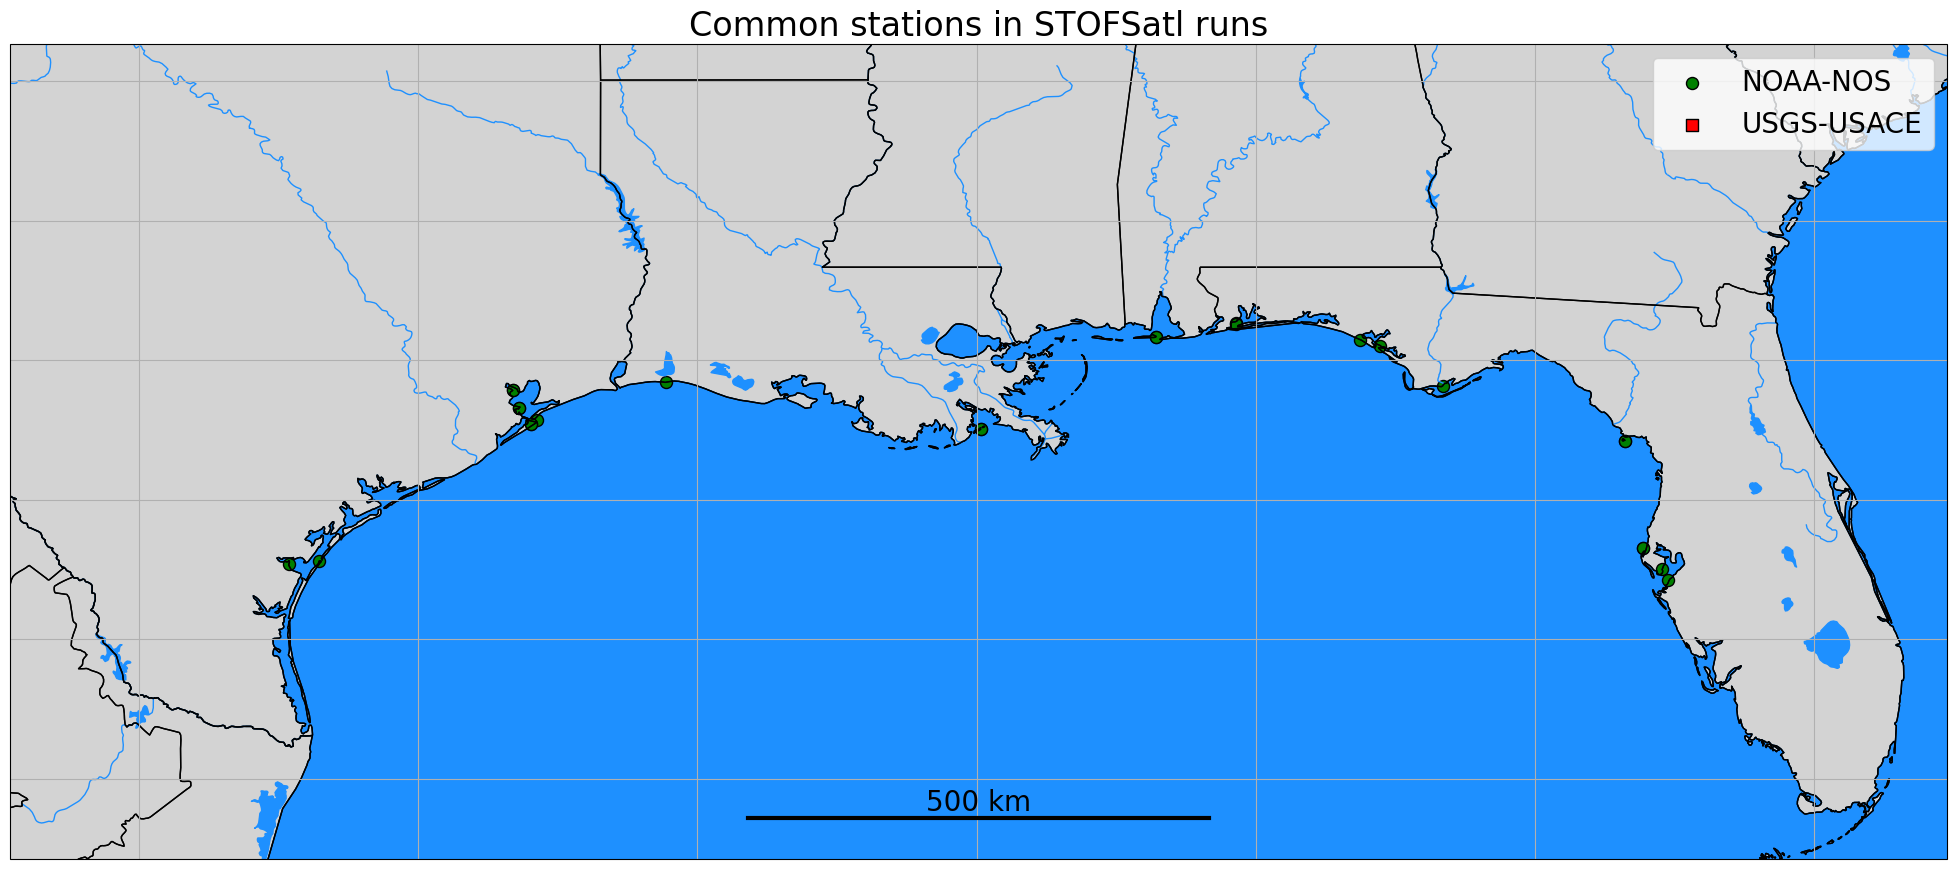

In [31]:
station_info_df_NOOA = station_info_df[(station_info_df['agency'] == 'NOAA_NOS') | (station_info_df['agency'] == 'TCOON')]
station_info_df_USGS = station_info_df[(station_info_df['agency'] == 'USGS') | (station_info_df['agency'] == 'USACE')]



plt.rcParams['figure.figsize'] = [25, 12.5]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

im1 = ax.scatter(station_info_df_NOOA['x'], station_info_df_NOOA['y'], c = 'green',
                  edgecolors='black',
                    s=75,
                      alpha=1.0,
                        label='NOAA-NOS')
im2 = ax.scatter(station_info_df_USGS['x'], station_info_df_USGS['y'], c = 'red',
                  marker = 's',
                    edgecolors='black',
                      s=75, alpha=1.0,
                        label='USGS-USACE')

plt.xlim((station_info_df['x'].min()-3, station_info_df['x'].max()+3))
plt.ylim((station_info_df['y'].min()-3, station_info_df['y'].max()+3))

plt.legend()
scale_bar(ax, 500)
plt.title('Common stations in STOFSatl runs')
plt.show()

In [32]:
# # 'TRAIN_STORMS': ['CHARLEY', 'HERMINE', 'MATTHEW', 'HARVEY', 'IDA'],
# # 'VAL_STORMS': ['IDALIA'],
# # 'TEST_STORMS': ['IAN'],

# # target_id = station_df.columns[40]
# target_id = '8726724'
# storms = config['SPLITS']['TRAIN_STORMS'] + config['SPLITS']['VAL_STORMS'] + config['SPLITS']['TEST_STORMS']

# # fig, ax = plt.subplots(1, len(storms), sharey=True, sharex=True)
# fig, ax = plt.subplots(1, len(storms), sharey=True)

# for i, storm in enumerate(storms):    
#     target_offset = data_df[(data_df['station_id']==target_id) & (data_df['storm']==storm)]['offset'].dropna()
#     ax[i].plot(range(len(target_offset)), target_offset)
#     ax[i].set_title(storm)
#     # ax[i].set_xticks([])

# target_name = data_df['station_name'].where(data_df['station_id']==target_id).dropna().unique()[0]
# fig.suptitle(f'{target_name} ({target_id})')
# plt.show()



# fig = plt.figure()
# ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# # fig, ax = plt.subplots()
# ax.set_global()
# # ax.stock_img()
# ax.add_feature(cfeature.COASTLINE, edgecolor="black")
# ax.add_feature(cfeature.BORDERS, edgecolor="black")
# ax.add_feature(cfeature.LAND, color="lightgrey")
# ax.add_feature(cfeature.LAKES, color="dodgerblue")
# ax.add_feature(cfeature.BORDERS, linestyle="--")
# ax.add_feature(cfeature.OCEAN, color="dodgerblue")
# ax.add_feature(cfeature.RIVERS, color="dodgerblue")
# ax.add_feature(cfeature.STATES)
# ax.gridlines()

# x = data_df[data_df['station_id']==target_id]['x'].unique()[0]
# y = data_df[data_df['station_id']==target_id]['y'].unique()[0]


# im1 = ax.scatter(x, y, c = 'red',
#                   edgecolors='black',
#                     s=75,
#                       alpha=1.0)


# plt.xlim((station_info_df['x'].min()-3, station_info_df['x'].max()+3))
# plt.ylim((station_info_df['y'].min()-3, station_info_df['y'].max()+3))

# scale_bar(ax, 500)
# plt.show()


In [33]:
# # Test windowing
# sliding_step = 1

# n_window = config['N_PRED'] + config['N_HIST'] # full window length

# # config['N_Windows']=int(len(station_df)/n_window)  # Works only for non-overlapping windows
# config['N_Windows'] = int((len(station_df) - n_window)/sliding_step)+1

# x = np.ones((station_df.shape[1], config['N_HIST']*config['N_Windows']))*np.nan
# y = np.ones((station_df.shape[1], config['N_PRED']*config['N_Windows']))*np.nan


# # full_window = np.ones((station_df.shape[1], n_window*config['N_Windows']))*np.nan

# # print(n_window)
# # print(sliding_step)
# # print(config['N_Windows'])

# # print(full_window.shape[1])


# for count, i in enumerate(range(0, len(station_df), sliding_step)):

#     sta=i
#     end = sta + n_window
    
#     if end > len(station_df):
#         break

#     data=np.array(station_df.iloc[sta:end,:].values)
#     data=np.swapaxes(data, 0, 1) #data is the offset of all stations

#     x[:,count*config['N_HIST']:count*config['N_HIST']+config['N_HIST']] = data[:, :config['N_HIST']]
#     y[:,count*config['N_PRED']:count*config['N_PRED']+config['N_PRED']] = data[:, config['N_HIST']::]

In [34]:
# # Test: Create station_df
# Ids=data_df['station_id'].unique()   
# station_df=create_stationDf(data_df,Ids, 'offset')

# print(station_df.columns)
# station_ids = station_df.columns
# data_train = data_df[data_df['storm'].isin(config['SPLITS']['TRAIN_STORMS'])]
# data_val = data_df[data_df['storm'].isin(config['SPLITS']['TRAIN_STORMS'])]
# data_test = data_df[data_df['storm'].isin(config['SPLITS']['TRAIN_STORMS'])]

# data_train



In [35]:
train_gnn, val_gnn, test_gnn, scaler=prepare_gnn_data(data_df, config, 500, 0.6)

19


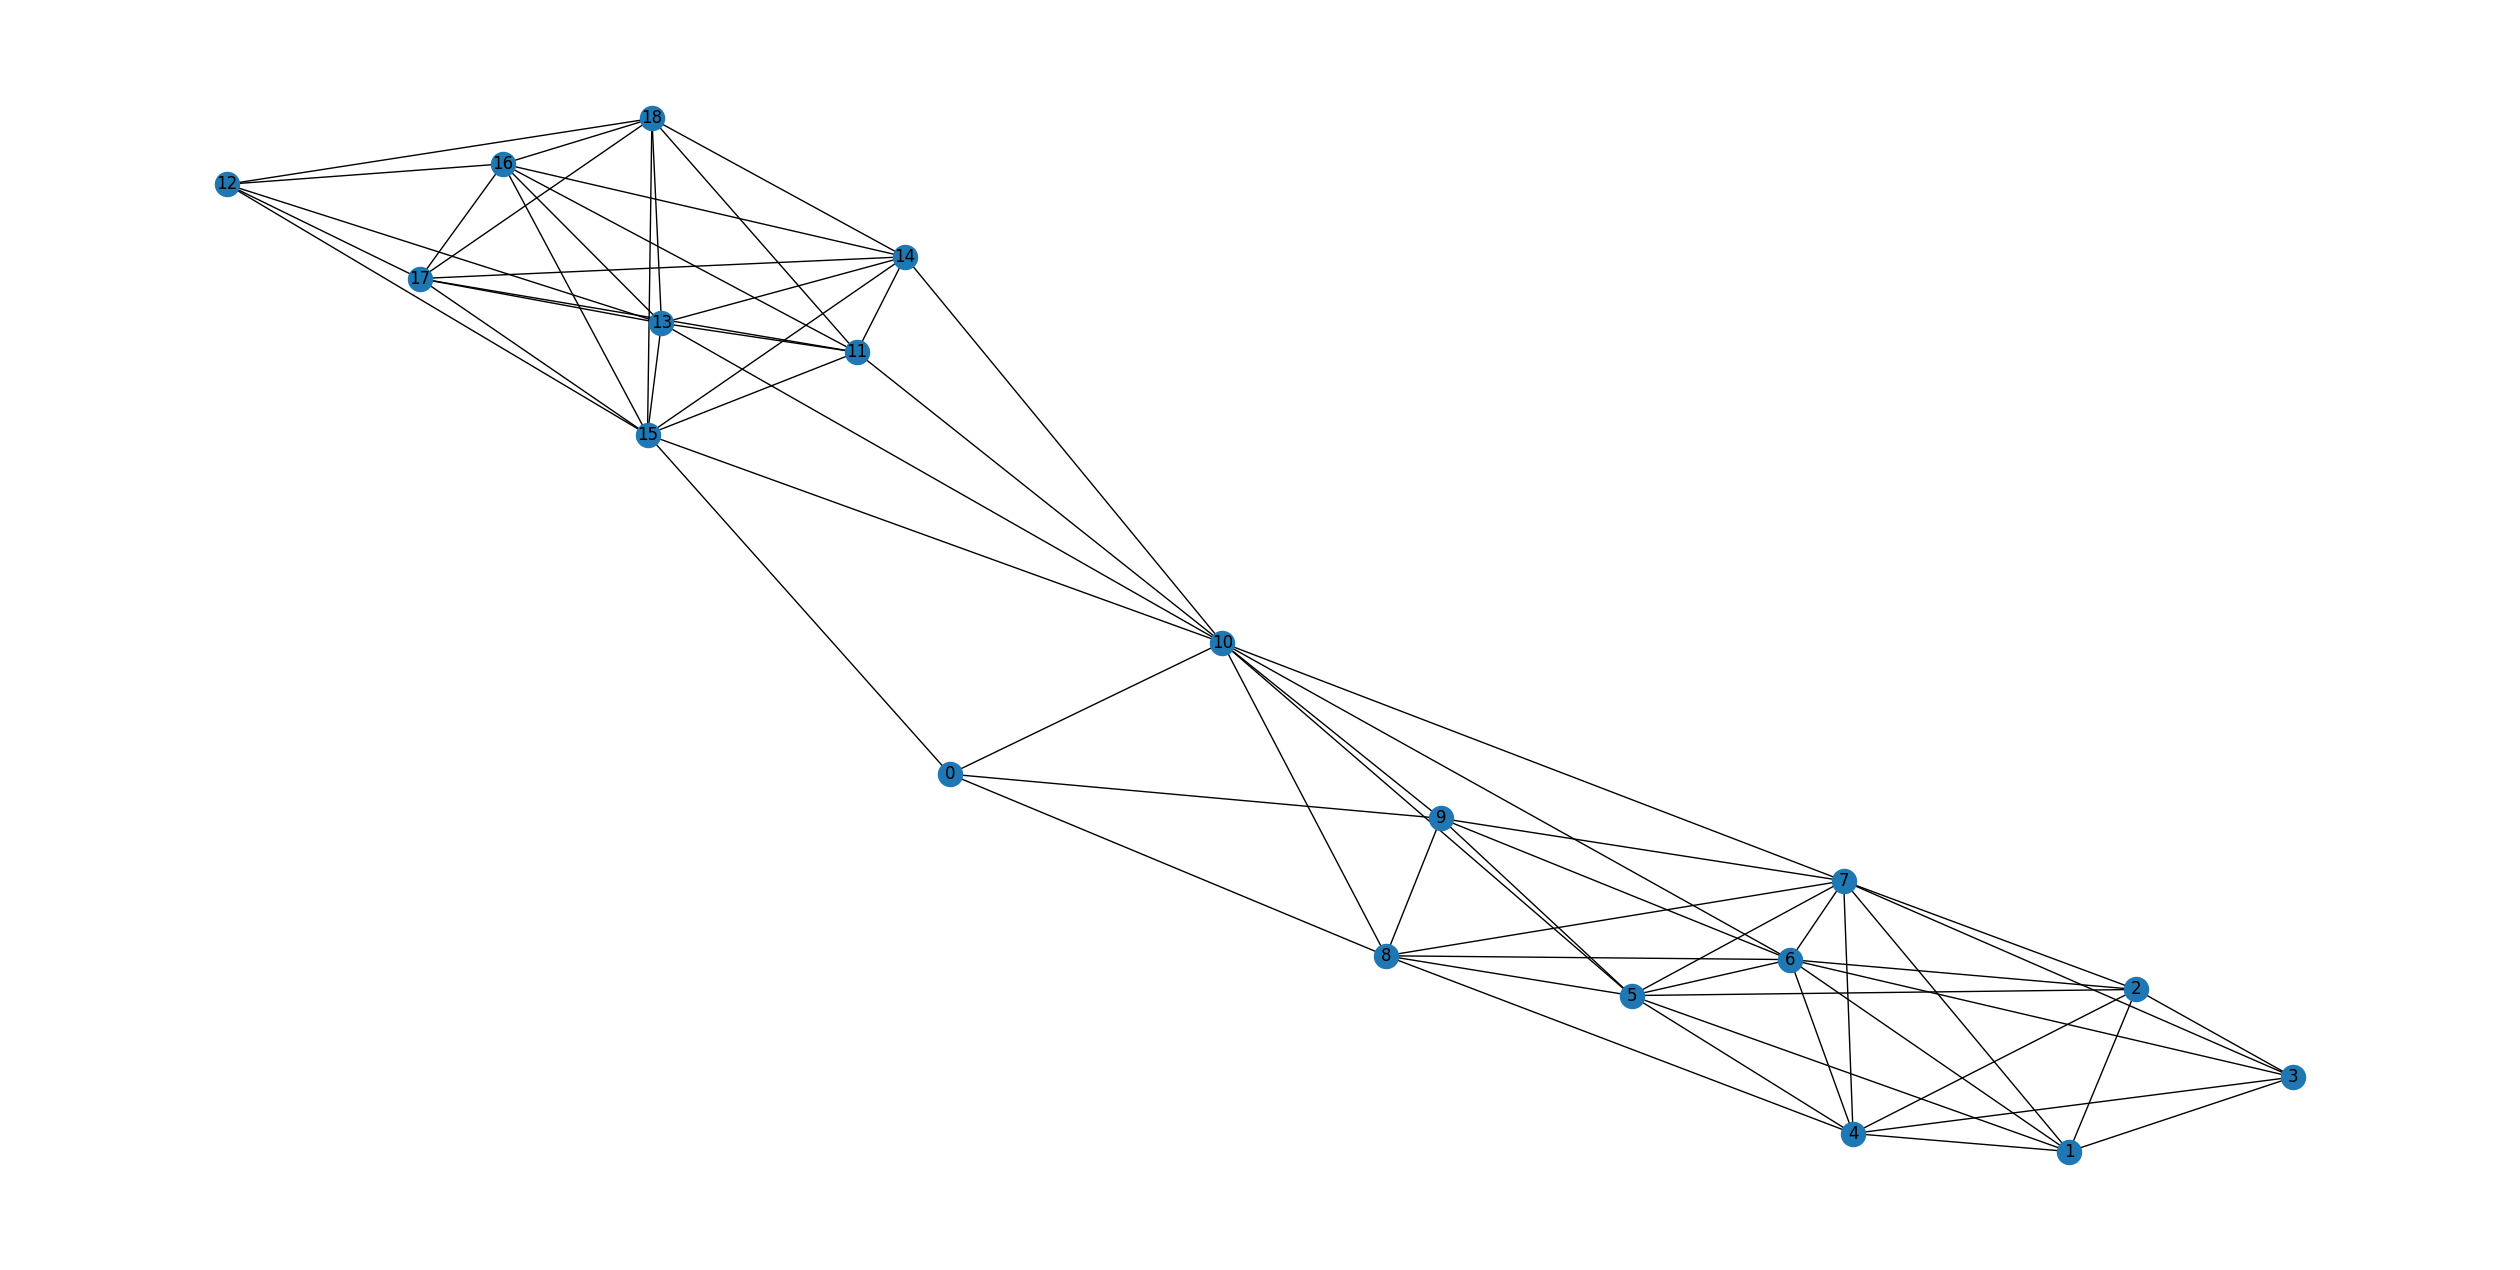

In [36]:
import networkx as nx
from torch_geometric.utils import to_networkx

g = to_networkx(train_gnn[0], to_undirected=True)
nx.draw(g, with_labels=True)
plt.show()

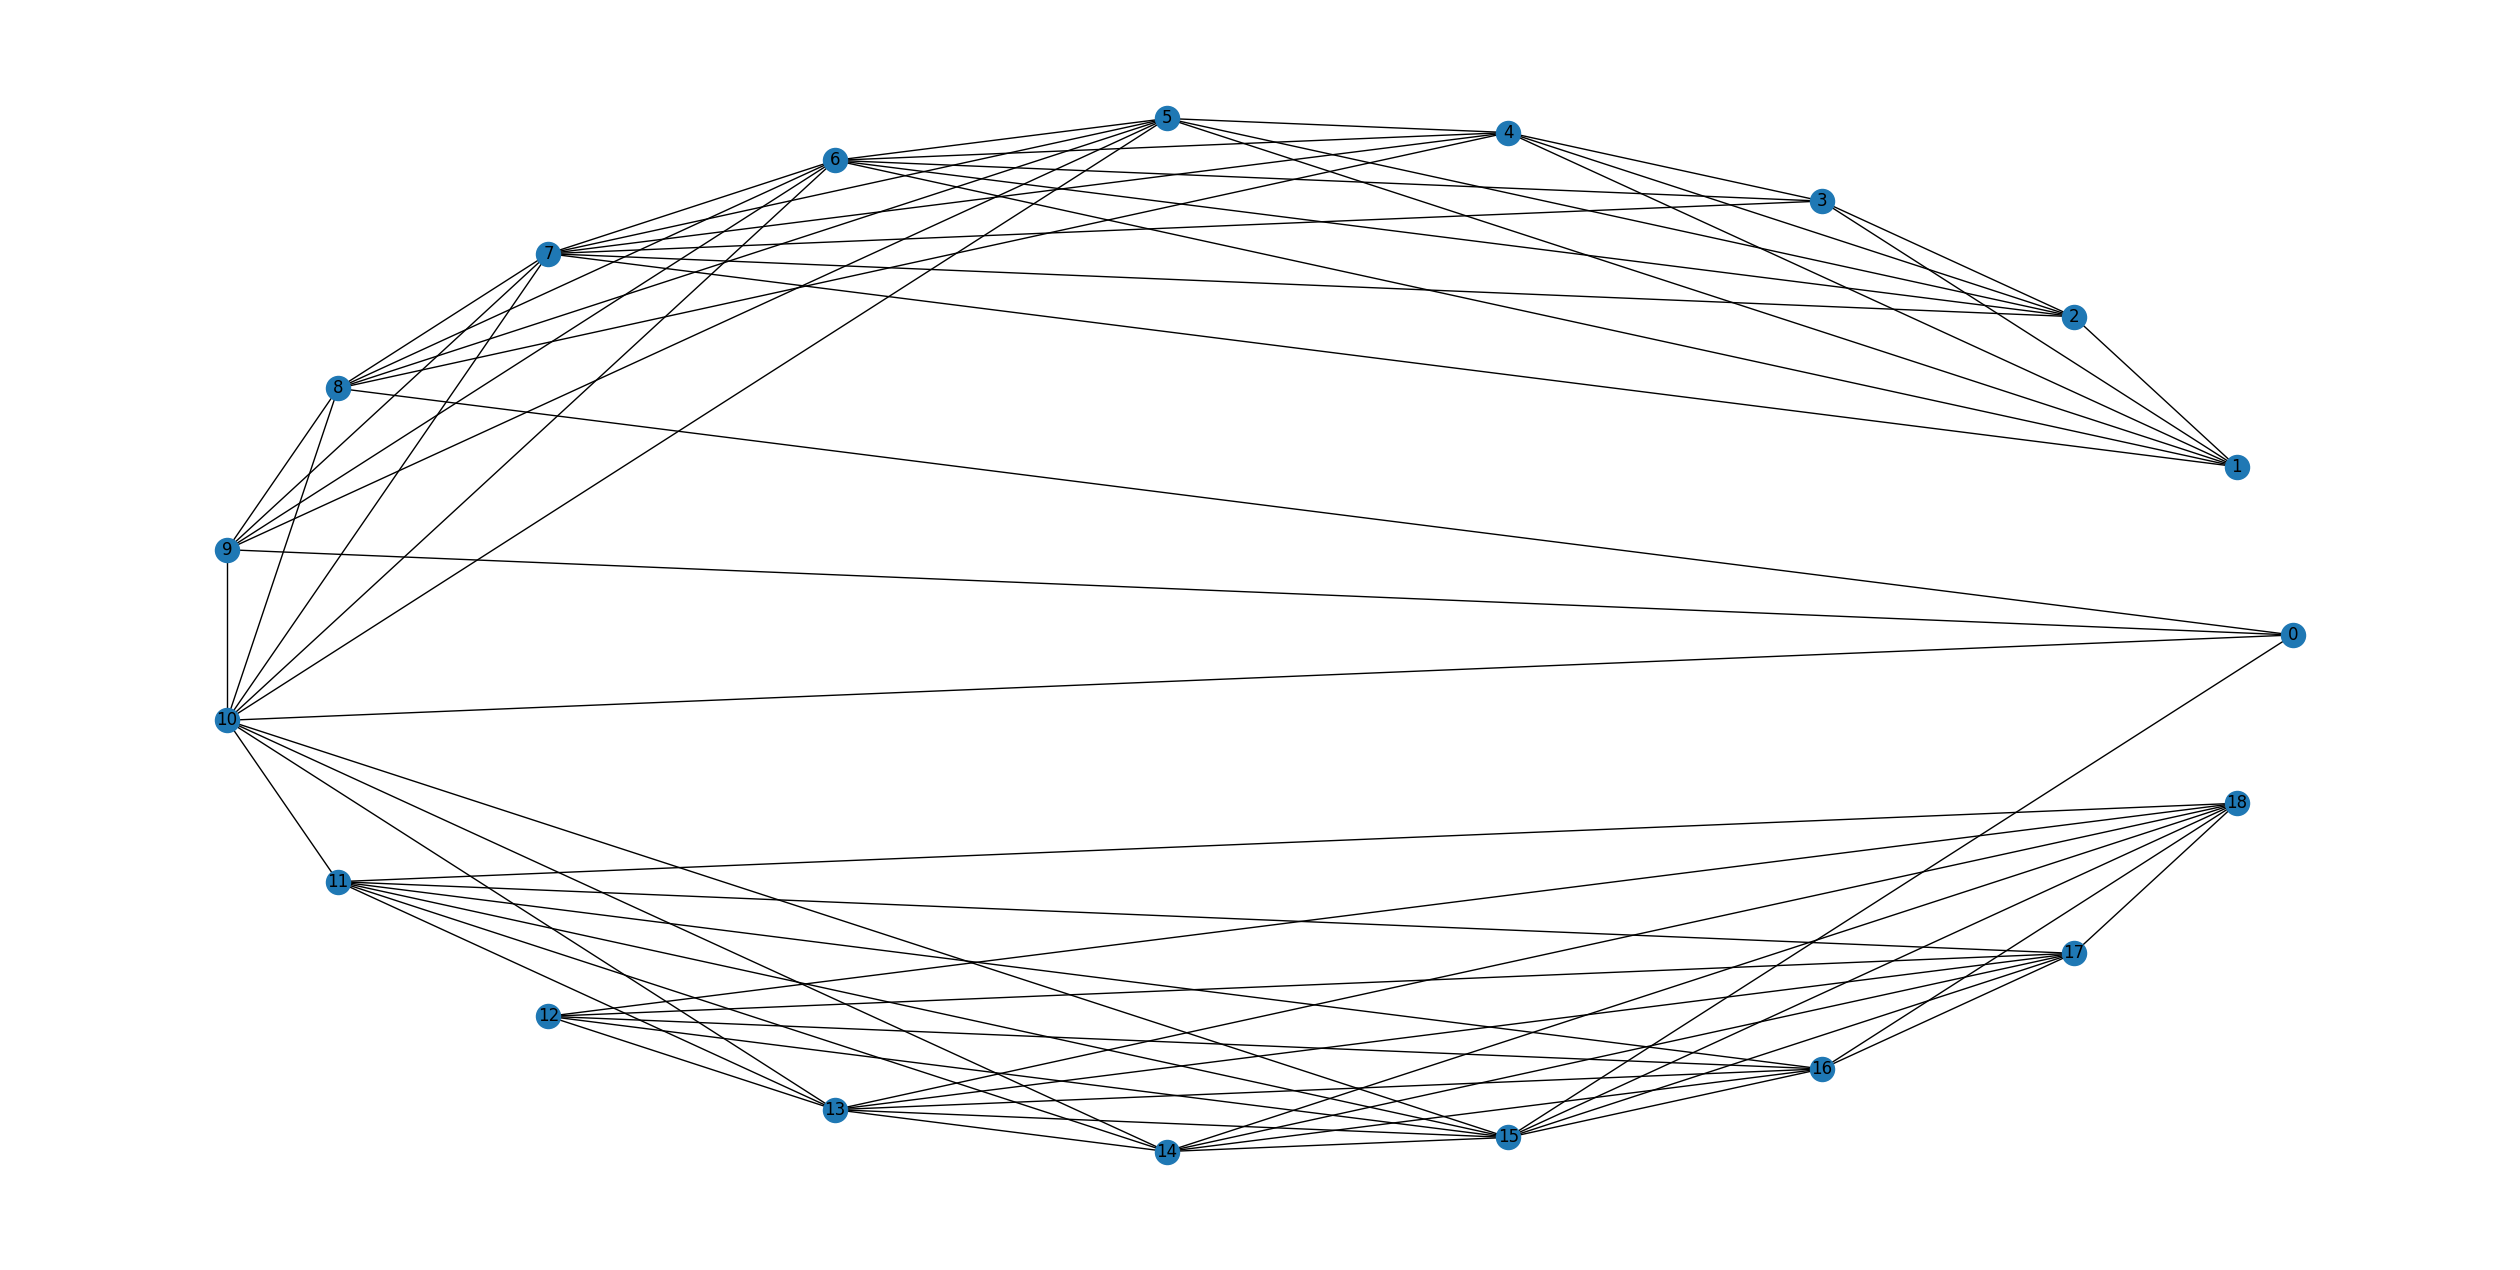

In [37]:
# g = to_networkx(test_gnn[0])
nx.draw_circular(g, with_labels=True)
plt.show()

In [38]:
print(len(g))
len(station_df_train.columns)

19


19

c:\Users\stefanos\Documents\venv\pytorch\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


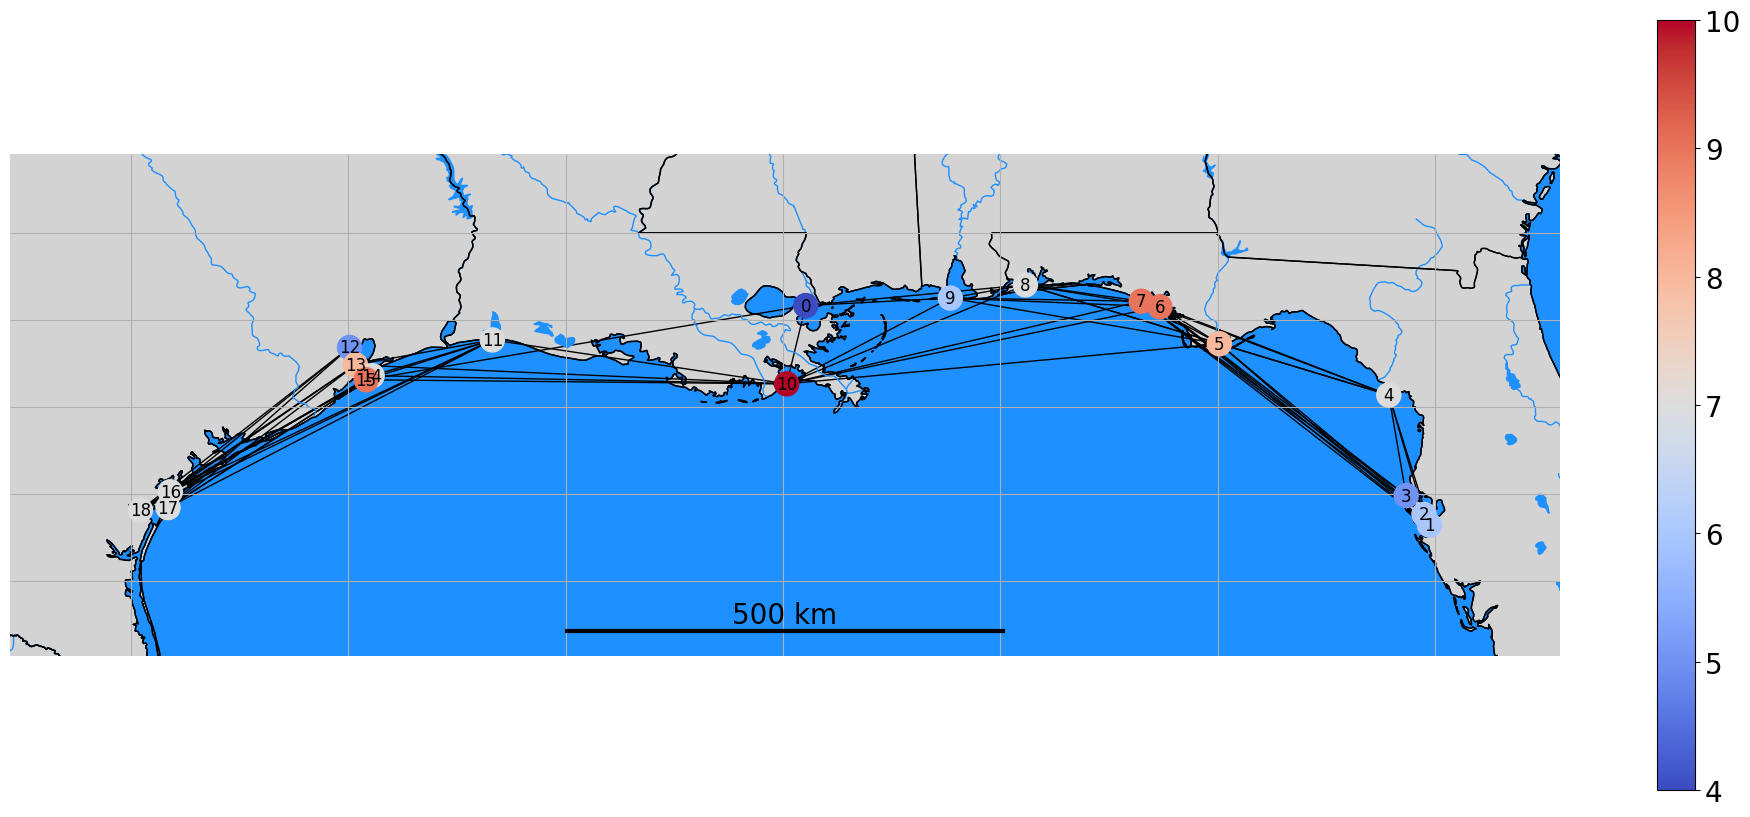

In [39]:
# drop_list = [station_df_train.columns[53], station_df_train.columns[71], station_df_train.columns[72], station_df_train.columns[73]]
# station_df_train.drop(drop_list, axis=1, inplace=True)
# station_df_val.drop(drop_list, axis=1, inplace=True)
# station_df_test.drop(drop_list, axis=1, inplace=True)

# mapping = {}
positions = {}
names = {}
ids = {}
agencies = {}

for node_name in g.nodes:
    # mapping[node_name]=station_df_train.columns[node_name]
    x = data_df['x'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    y = data_df['y'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    names[node_name] = data_df['station_name'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    ids[node_name] = data_df['station_id'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    agencies[node_name] = data_df['agency'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    # positions[station_df.columns[node_name]] = (x,y)
    positions[node_name] = (x,y)

# g = nx.relabel_nodes(g, mapping)
plt.rcParams['figure.figsize'] = [25, 10]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

d = dict(g.degree)
low, *_, high = sorted(d.values())
norm = mpl.colors.Normalize(vmin=low, vmax=high, clip=True)
mapper = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.coolwarm)

nx.draw(g, pos=positions, with_labels=True, node_color=[mapper.to_rgba(i) for i in d.values()])

# nx.draw_networkx_nodes(g, pos=positions, node_color=[mapper.to_rgba(i) for i in d.values()])
# nx.draw_networkx_labels(g, pos=positions)


plt.xlim((station_info_df['x'].min()-1.5, station_info_df['x'].max()+1.5))
plt.ylim((station_info_df['y'].min()-1.5, station_info_df['y'].max()+1.5))

scale_bar(ax, 500)
fig.colorbar(mapper, ax=ax)
plt.show()

In [40]:
print(positions[1])

# # xlim
print(positions[7])

# # ylim
print(positions[8])

(np.float64(-82.5625), np.float64(27.638333))
(np.float64(-85.878583), np.float64(30.21375))
(np.float64(-87.211197), np.float64(30.401688))


In [41]:
# id0 = station_df_test.columns[69]
# df_test[df_test['station_id']==id0]['station_name'].dropna().unique()[0]


In [42]:
# id1 = station_df_test.columns[62]
# y1 = df_test[df_test['station_id']==id1]['y'].dropna().unique()[0]
# x1 = df_test[df_test['station_id']==id1]['x'].dropna().unique()[0]

# id2 = station_df_test.columns[68]
# y2 = df_test[df_test['station_id']==id2]['y'].dropna().unique()[0]
# x2 = df_test[df_test['station_id']==id2]['x'].dropna().unique()[0]

# print(haversine(y1, x1, y2, x2))


In [43]:
# data_df['station_id'].where(data_df['station_id']==str(station_df_train.columns[52])).dropna().unique()[0]

In [44]:
# test_gnn

In [45]:
# test_gnn[0].x[0]

In [46]:
# test_gnn[1].x[0]

In [47]:
from torch_geometric.loader import DataLoader

train_dataloader = DataLoader(train_gnn, batch_size=config['BATCH_SIZE'], shuffle=True)
val_dataloader = DataLoader(val_gnn, batch_size=config['BATCH_SIZE'], shuffle=True)
test_dataloader = DataLoader(test_gnn, batch_size=14, shuffle=False) # find a divisor of 143

In [48]:
# print(len(test_dataloader.dataset))

In [49]:
# print(test_dataloader.batch_size)

In [50]:
# test_dataloader.dataset

In [51]:
from models.trainer import load_from_checkpoint, model_train, model_test
from torch_geometric.loader import DataLoader


 # Get gpu if you can
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

# Configure and train model
config['N_NODE'] = train_gnn[0].x.shape[0]
print(config['N_NODE'])
model = model_train(train_dataloader, val_dataloader, config, device)

Using cpu
19


Epoch 0: 100%|██████████| 15/15 [00:02<00:00,  7.39it/s]


Loss: 0.331
Train, MAE: 0.5232642292976379, RMSE: 0.5504764318466187
Valid, MAE: 0.49402403831481934, RMSE: 0.5147297382354736
Train, MAE: 0.5237349271774292, RMSE: 0.5510799884796143
Valid, MAE: 0.49402403831481934, RMSE: 0.5147361755371094


Epoch 1: 100%|██████████| 15/15 [00:01<00:00, 10.23it/s]


Loss: 0.292
Train, MAE: 0.5198346376419067, RMSE: 0.5478436946868896
Valid, MAE: 0.49167338013648987, RMSE: 0.5125276446342468


...

Loss: 0.008
Train, MAE: 0.05516406521201134, RMSE: 0.08026690036058426
Valid, MAE: 0.10460446029901505, RMSE: 0.13563235104084015


Epoch 198: 100%|██████████| 15/15 [00:01<00:00, 10.36it/s]


Loss: 0.004
Train, MAE: 0.05476761609315872, RMSE: 0.08005265891551971
Valid, MAE: 0.10435586422681808, RMSE: 0.13462480902671814


Epoch 199: 100%|██████████| 15/15 [00:01<00:00, 11.39it/s]


Loss: 0.006
Train, MAE: 0.055844251066446304, RMSE: 0.08055955916643143
Valid, MAE: 0.10479079931974411, RMSE: 0.1358080953359604


In [52]:
# enumerate(test_dataloader)

In [53]:
# for i, batch in enumerate(test_dataloader):
#     print(i)
#     batch = batch.to(device)
#     if batch.x.shape[0] == 1:
#         pass
#     else:
#         # plt.figure()
#         with torch.no_grad():
#             # print(batch.y[0])
#             pred = model(batch, device)
        
#         truth = batch.y.view(pred.shape)
#         # print(pred[0])
#         # print(pred[6])

#         # plt.plot(truth[-1,:])
#         # plt.plot(pred[-1,:])
#         # plt.show()


#         if i == 0:
#             y_pred = torch.zeros(len(test_dataloader), pred.shape[0], pred.shape[1])
#             y_truth = torch.zeros(len(test_dataloader), pred.shape[0], pred.shape[1])
#         # truth = un_z_score(truth, dataloader.dataset.mean, dataloader.dataset.std_dev)
#         # pred = un_z_score(pred, dataloader.dataset.mean, dataloader.dataset.std_dev)
#         y_pred[i, :pred.shape[0], :] = pred
#         # print(y_pred)
#         y_truth[i, :pred.shape[0], :] = truth
#         # print(y_truth)


# s = y_truth.shape
# num=int(s[1]* s[-1])
# num2=config['N_NODE']*s[-1] 
# y_truth = y_truth.reshape(s[0], int(num/num2), config['N_NODE'], s[-1])
# print(y_truth.shape)

# # Calculate the predicted
# s = y_pred.shape
# y_pred = y_pred.reshape(s[0], int(num/num2) ,config['N_NODE'], s[-1])

# # Inverse scaling
# y_truth = scaler.inverse_transform(y_truth.reshape(-1,1)).reshape(y_truth.shape[0], y_truth.shape[1], y_truth.shape[2], y_truth.shape[3])
# y_pred = scaler.inverse_transform(y_pred.reshape(-1,1)).reshape(y_pred.shape[0], y_pred.shape[1], y_pred.shape[2], y_pred.shape[3])

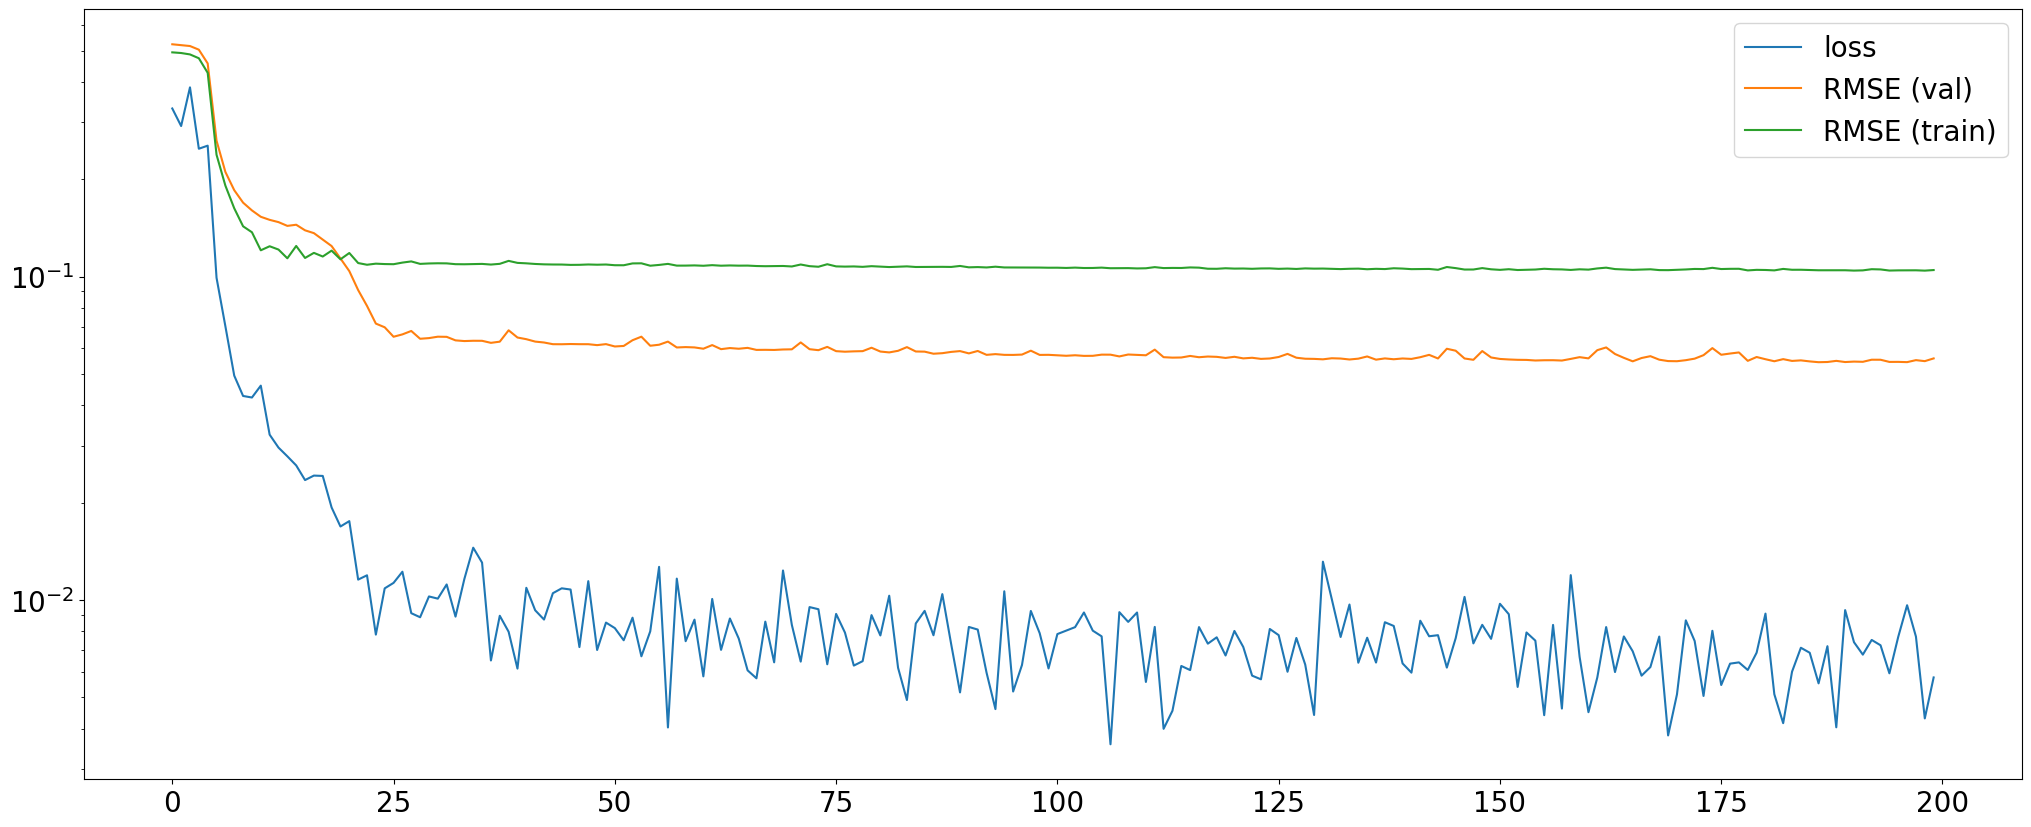

In [54]:
plt.plot(model[1], label='loss')
plt.plot(model[2], label='RMSE (val)')
plt.plot(model[3], label='RMSE (train)')
plt.yscale('log')
plt.legend()
plt.show()

In [55]:
predictions = []
ground_truths = []

for i, batch in enumerate(test_dataloader):
    batch = batch.to(device)
    print(batch.size)
    if batch.x.shape[0] == 1:
        pass
    else:
        with torch.no_grad():
            pred = model[0](batch, device)

        truth = batch.y.to(device)  # Ensure it's on the same device

        predictions.append(pred)
        ground_truths.append(truth)

        


predictions = torch.cat(predictions, dim=0)
ground_truths = torch.cat(ground_truths, dim=0)
num_nodes = config['N_NODE']  # Number of nodes per graph = 74-1
num_features = predictions.shape[1]  # Number of features per node
num_graphs = predictions.shape[0] // num_nodes  # Total number of graphs

# Reshape predictions
reshaped_predictions = predictions.view(num_graphs, num_nodes, num_features)
reshaped_truth=ground_truths.view(num_graphs, num_nodes, num_features)
print("Reshaped Predictions shape:", reshaped_predictions.shape)

<bound method BaseData.size of DataBatch(edge_index=[2, 1876], edge_attr=[14], x=[266, 15], y=[266, 9], batch=[266], ptr=[15])>
<bound method BaseData.size of DataBatch(edge_index=[2, 402], edge_attr=[3], x=[57, 15], y=[57, 9], batch=[57], ptr=[4])>
Reshaped Predictions shape: torch.Size([17, 19, 9])


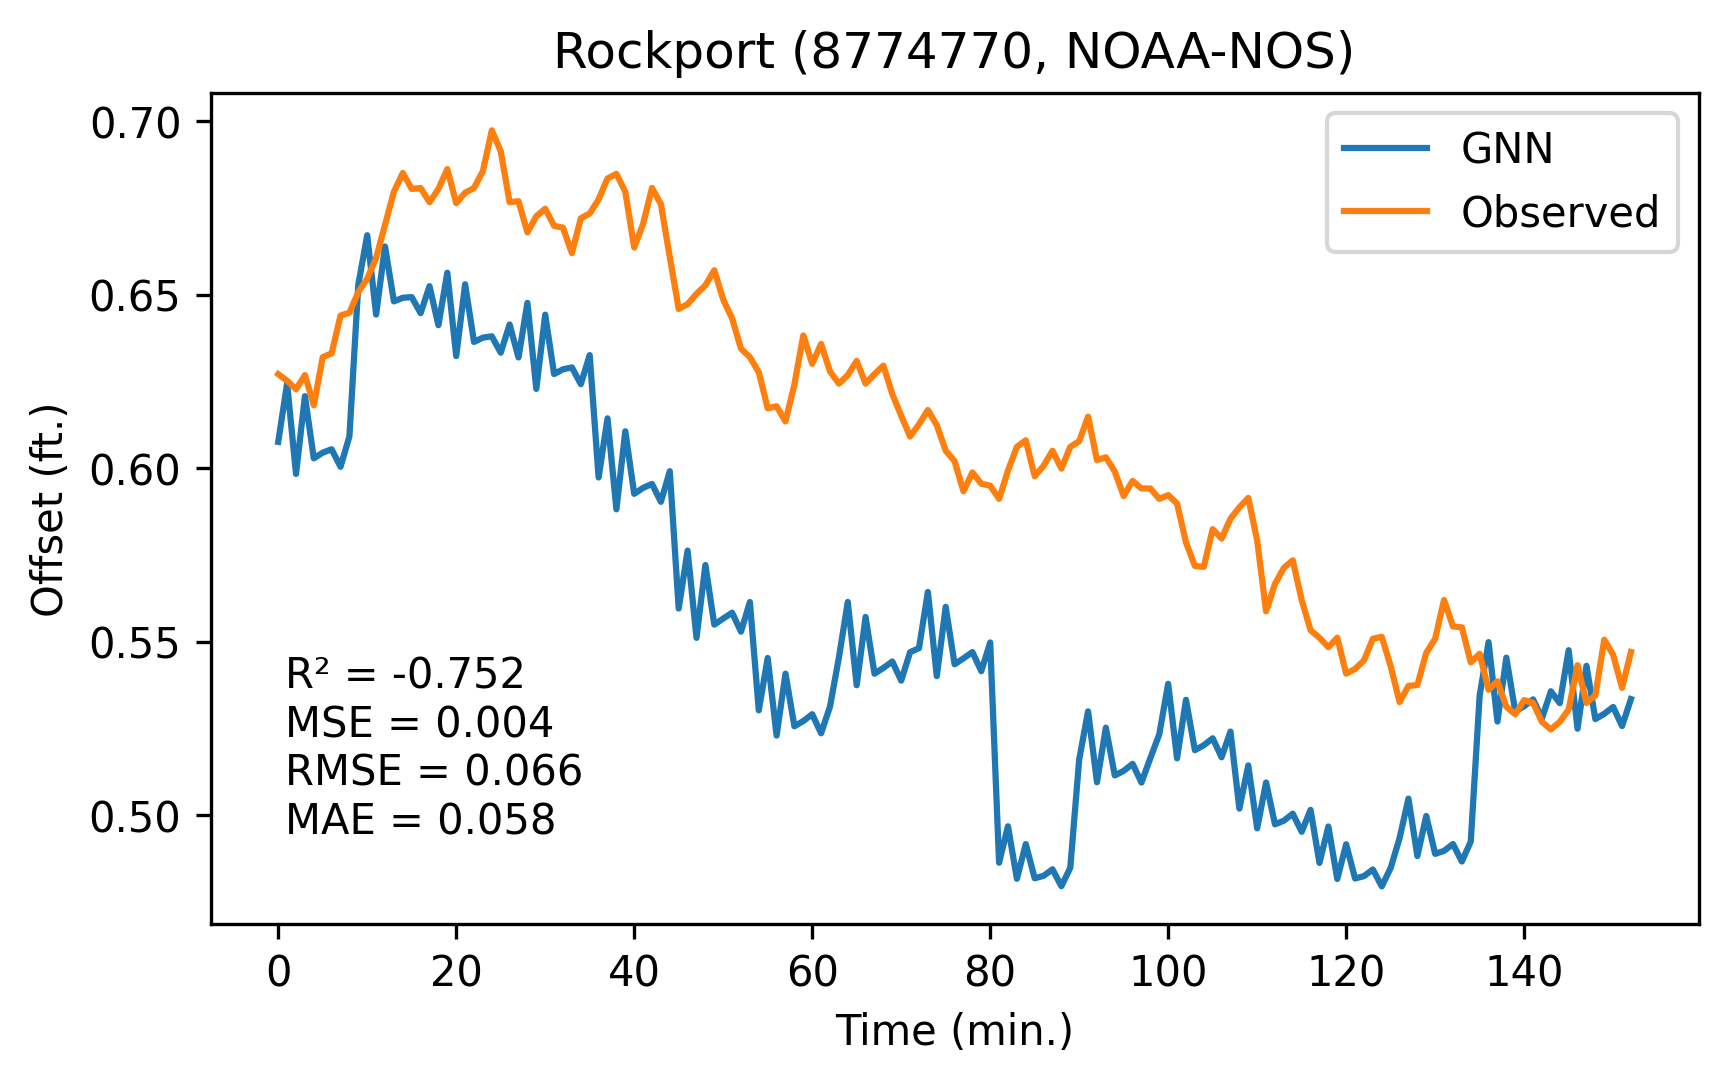

In [56]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = [6.4, 3.6]
plt.rcParams.update({'font.size': 10})
plt.rcParams['figure.dpi'] = 300

# Select the node index (e.g., node 5)
node_index = 16

# # Reshape predictions to [num_graphs, num_nodes, num_features]

# Extract the predictions for the specific node across all graphs
node_pred = reshaped_predictions[:, node_index, :].reshape(-1)  # Shape: [num_graphs, num_features]
node_truth = reshaped_truth[:, node_index, :].reshape(-1)  # Shape: [num_graphs, num_features]
# node_truth[]
# Print the shape
# print("Node Time Series shape:", node_time_series.shape)  # [num_graphs, num_features]

plt.figure()
plt.plot(node_pred,label='GNN')
plt.plot(node_truth, label='Observed')
plt.legend()
title_str = f'{names[node_index]} ({ids[node_index]}, {agencies[node_index].replace("_", "-")})'
plt.title(title_str)

r_sq_str = "R\u00b2 = {:.3f}\n".format(r2_score(node_truth, node_pred))
mse_str = "MSE = {:.3f}\n".format(mean_squared_error(node_truth, node_pred))
rmse_str = "RMSE = {:.3f}\n".format(root_mean_squared_error(node_truth, node_pred))
mae_str = "MAE = {:.3f}\n".format(mean_absolute_error(node_truth, node_pred))
stat_str = r_sq_str + mse_str + rmse_str + mae_str
plt.annotate(stat_str, xy=(0.05, 0.05), xycoords='axes fraction')

plt.ylabel('Offset (ft.)')
plt.xlabel('Time (min.)')
plt.show()
# # Print results
# print("Predictions:")
# print(predictions.shape)
# print("Ground Truths:")
# print(ground_truths.shape)

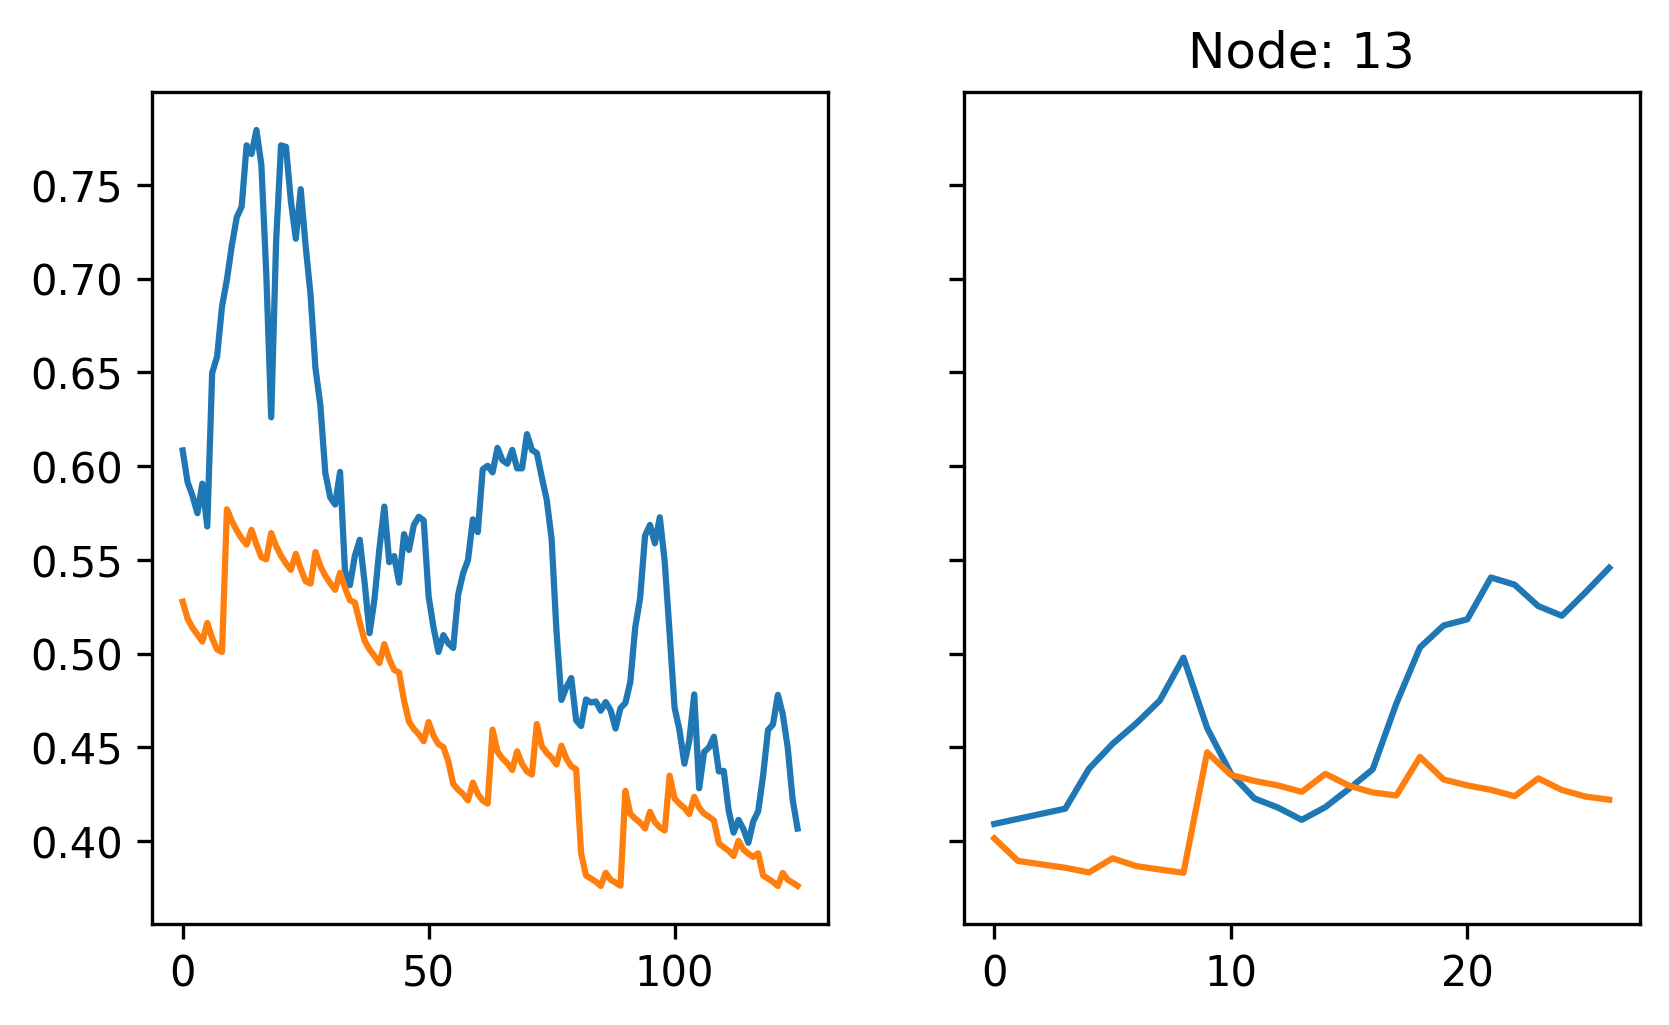

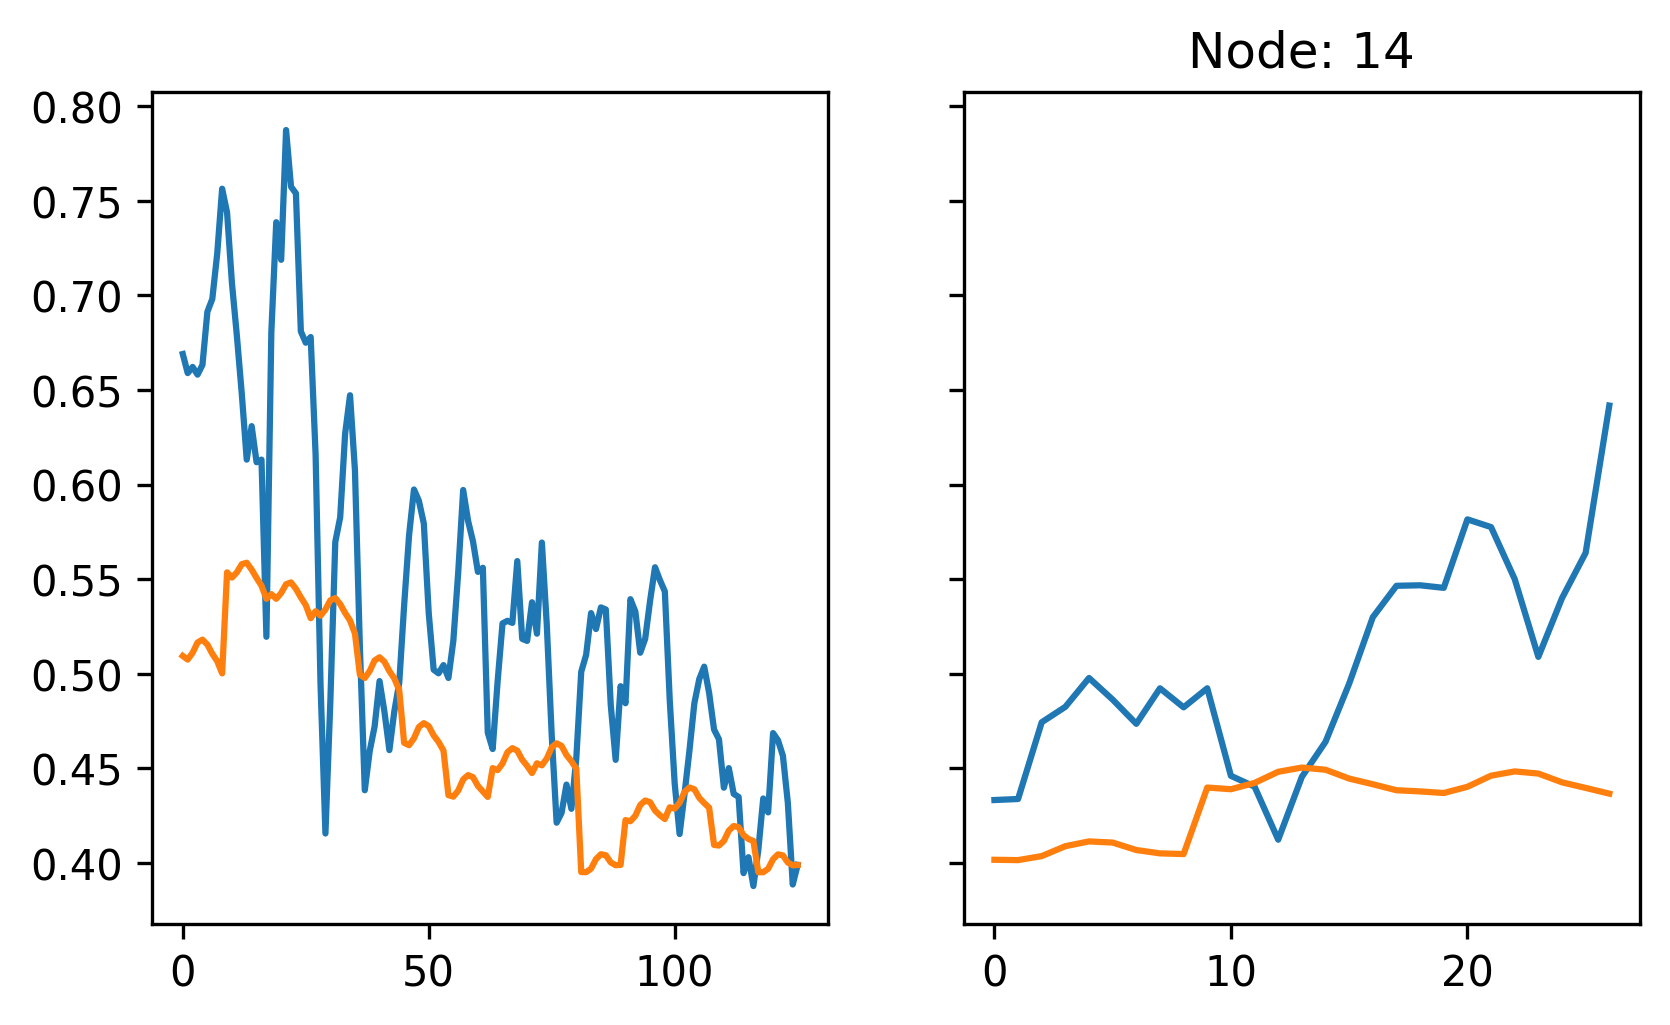

In [57]:
node=13
fig, ax = plt.subplots(1, len(test_dataloader), sharey=True)
for i, batch in enumerate(test_dataloader):
    # ax[count].plot(i.x[0,:])
    # print(batch)
    y_tr = batch.y.reshape(len(batch.edge_attr), config['N_NODE'], config['N_PRED'])
    # print(y_tr.shape)
    if len(test_dataloader)>1:
        ax[i].plot(y_tr[:,node,:].flatten())
    else:
        ax.plot(y_tr[:,node,:].flatten())

    batch = batch.to(device)
    # print(batch.size())
    if batch.x.shape[0] == 1:
        pass
    else:
        with torch.no_grad():
            pred = model[0](batch, device)
        pred = pred.reshape(len(batch.edge_attr), config['N_NODE'], config['N_PRED'])
        if len(test_dataloader)>1:
            ax[i].plot(pred[:,node,:].flatten())
        else:
            ax.plot(pred[:,node,:].flatten())
plt.title('Node: ' + str(node)) 
plt.show()

node=14
fig, ax = plt.subplots(1, len(test_dataloader), sharey=True)
for i, batch in enumerate(test_dataloader):
    # ax[count].plot(i.x[0,:])
    # print(batch)
    y_tr = batch.y.reshape(len(batch.edge_attr), config['N_NODE'], config['N_PRED'])
    # print(y_tr.shape)
    if len(test_dataloader)>1:
        ax[i].plot(y_tr[:,node,:].flatten())
    else:
        ax.plot(y_tr[:,node,:].flatten())

    batch = batch.to(device)
    # print(batch.size())
    if batch.x.shape[0] == 1:
        pass
    else:
        with torch.no_grad():
            pred = model[0](batch, device)
        pred = pred.reshape(len(batch.edge_attr), config['N_NODE'], config['N_PRED'])
        if len(test_dataloader)>1:
            ax[i].plot(pred[:,node,:].flatten())
        else:
            ax.plot(pred[:,node,:].flatten())
plt.title('Node: ' + str(node)) 
plt.show()

# plt.plot(station_df.iloc[:,3])
# plt.show()

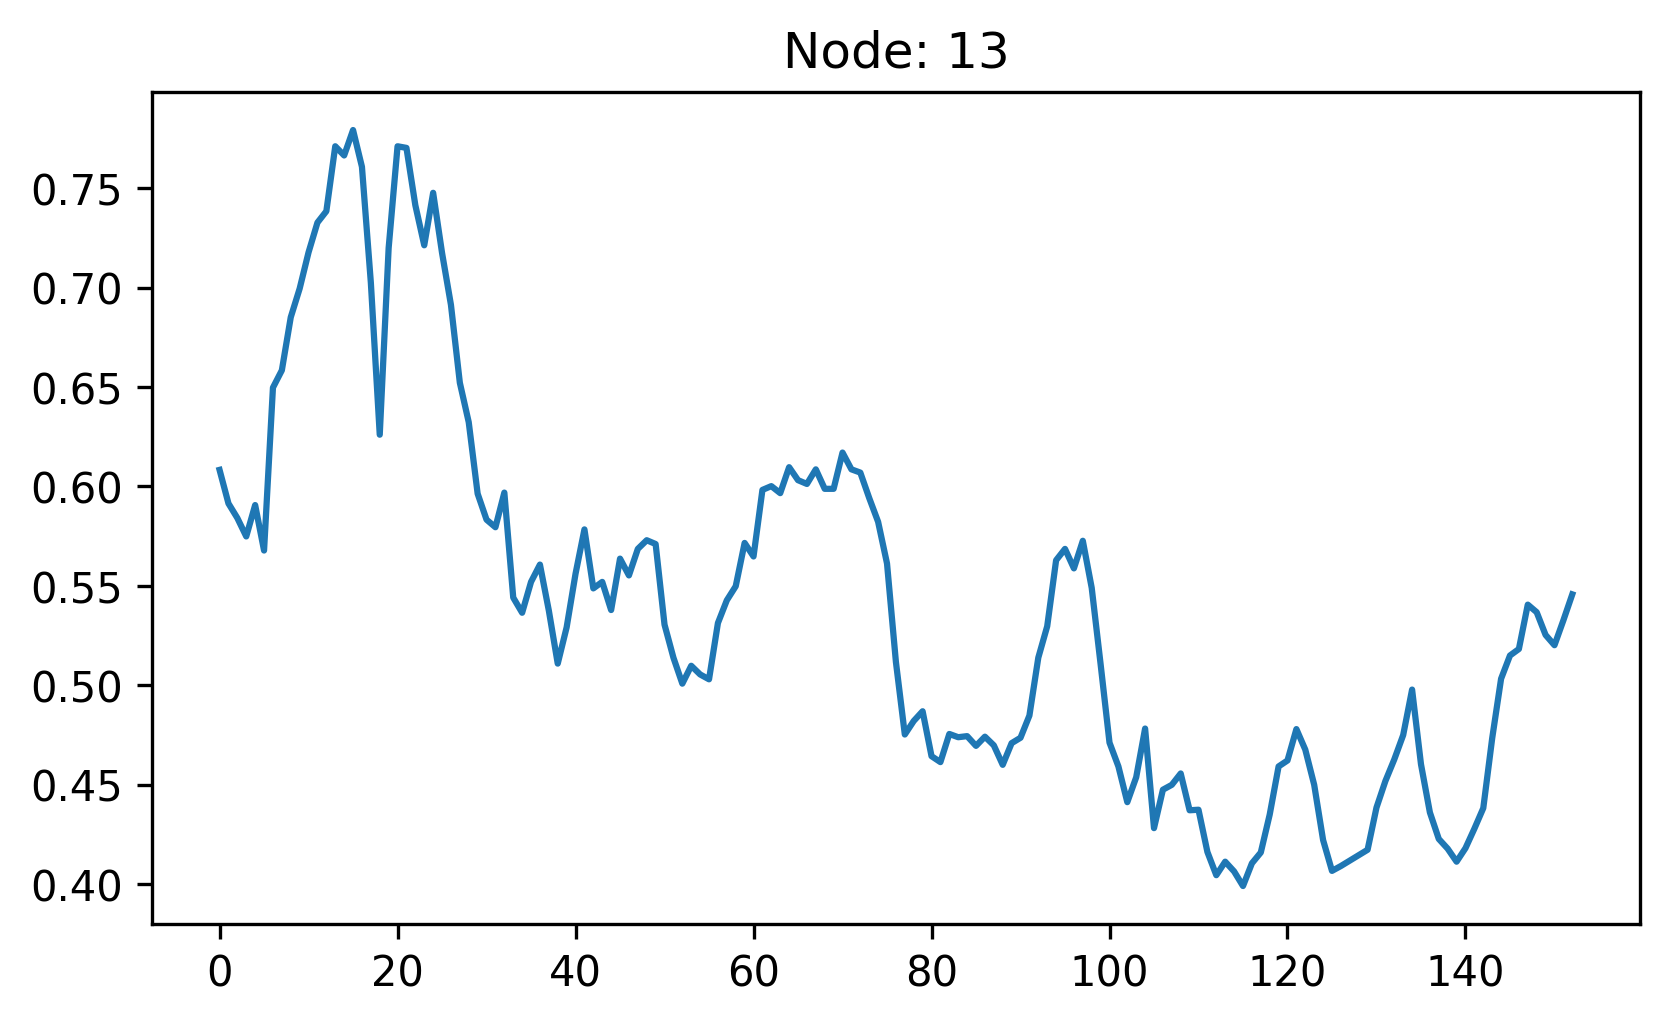

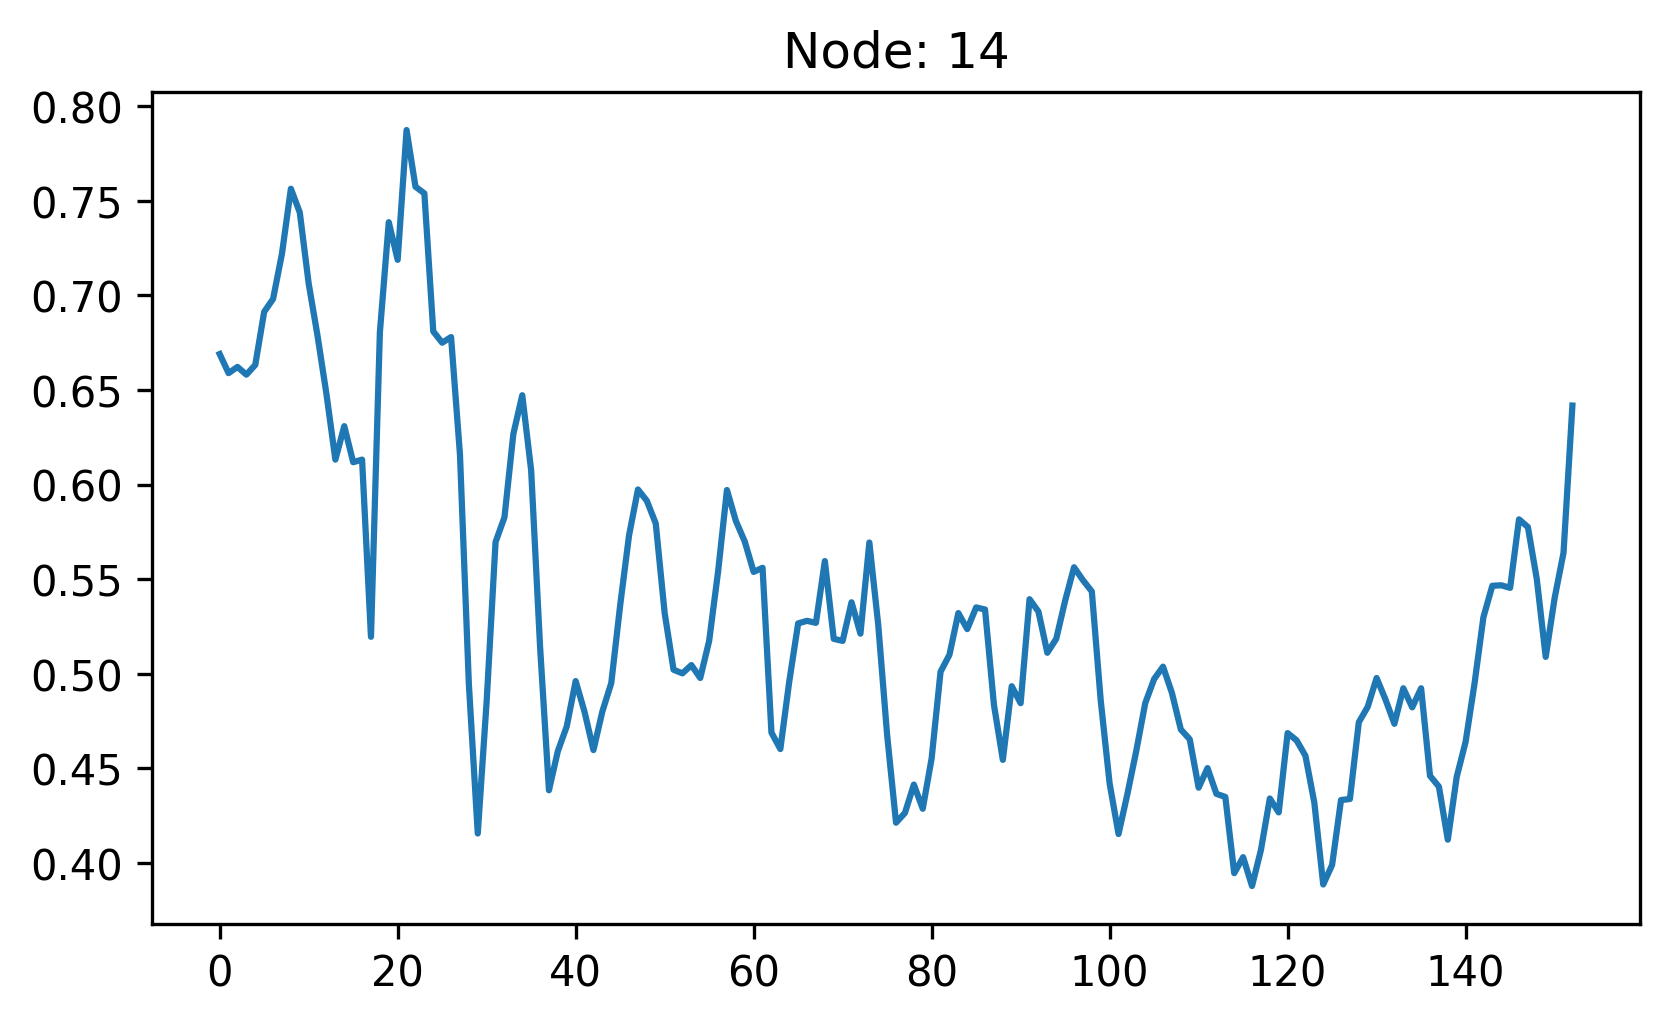

In [58]:
# Print truth data from the graph (test_gnn)

node=13
y_read = np.array([]).reshape(test_gnn[0].y.shape[0], 0)
for seq in range(len(test_gnn)):
    y_read_seq = test_gnn[seq].y.detach().numpy()
    y_read =np.concatenate((y_read, y_read_seq), axis=1)
plt.plot(y_read[node])
plt.title('Node: ' + str(node)) 
plt.show()

node=14
y_read = np.array([]).reshape(test_gnn[0].y.shape[0], 0)
for seq in range(len(test_gnn)):
    y_read_seq = test_gnn[seq].y.detach().numpy()
    y_read =np.concatenate((y_read, y_read_seq), axis=1)
plt.plot(y_read[node])
plt.title('Node: ' + str(node)) 
plt.show()